# Wind-tunnel analysis notebook — cleaned version

This notebook is a consolidated version of the current analysis workflow. It is intended to replace the repeated code blocks across the previous notebooks.

Main features:

- reads all `.lvm` files in one folder,
- parses clean and trip-wire filenames,
- computes mean \(C_p(\theta)\), \(C_D\), \(C_L\), RMS/variance of \(C_p\),
- computes Strouhal number from the time-resolved lift signal,
- stores everything in both `results_df` and `grouped_results`,
- includes reusable plotting functions for \(C_p\), \(C_D\) vs Re, \(C_L\) vs Re, normal-bar \(C_p\) plots, and batch uncertainty.

Expected filename formats:

```text
Cyl100v2_Re100k_Clean.lvm
Cyl100v2_Re100k_Trip_0.94_A27.lvm
```

Older names such as `Cyl100_Re100k_Clean.lvm` should also work, as long as the general structure is the same.


## 1. Imports and user settings

In [1]:
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# FIGURE FONT SETTINGS
# =========================
# Match this to the main text size in your LaTeX document.
# Examples:
#   \documentclass[10pt]{...} -> FIG_FONT_SIZE = 10
#   \documentclass[11pt]{...} -> FIG_FONT_SIZE = 11
#   \documentclass[12pt]{...} -> FIG_FONT_SIZE = 12
FIG_FONT_SIZE = 14

plt.rcParams.update({
    "font.size": FIG_FONT_SIZE,
    "axes.labelsize": FIG_FONT_SIZE,
    "axes.titlesize": FIG_FONT_SIZE,
    "xtick.labelsize": FIG_FONT_SIZE,
    "ytick.labelsize": FIG_FONT_SIZE,
    "legend.fontsize": FIG_FONT_SIZE,
    "figure.titlesize": FIG_FONT_SIZE,
})

# =========================
# REYNOLDS NUMBER AXIS SETTINGS
# =========================
# Re values are stored internally as full values, e.g. 100000.
# For plots, they are displayed as Re/1000, e.g. 100 for Re = 100000.
RE_AXIS_SCALE = 1000.0
RE_AXIS_LABEL = r"$Re \times 10^{3}$"

def re_axis_values(re_values):
    """Return Reynolds numbers scaled for plotting on the x-axis."""
    return np.asarray(re_values, dtype=float) / RE_AXIS_SCALE


# =========================
# USER SETTINGS
# =========================
# Default: use the folder where the notebook is opened from.
# If this does not find your .lvm files, replace Path.cwd() with your LVM folder, e.g.
# DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260514T000837Z-3-001\LVM")
DATA_FOLDER = Path(r"C:\Users\mpciv\Downloads\LVM-20260514T000837Z-3-001\LVM")

# Output folder for optional exported figures/tables.
OUTPUT_FOLDER = DATA_FOLDER / "processed_outputs"
OUTPUT_FOLDER.mkdir(exist_ok=True)

# Cylinder diameter [m].
D = 0.100

# 1-based pressure tap columns in the .lvm files.
# Layer 1: 0, 12, 24, ..., 348 degrees
# Layer 2: 6, 18, 30, ..., 354 degrees
LAYER1_COLS_1BASED = (1, 30)
LAYER2_COLS_1BASED = (33, 62)

# Extra channels. The first of these, "pitot", is used as q_inf.
EXTRA_NAMES = ["pitot", "AoA", "F", "alpha", "P_m", "V_tunnel", "rho", "time"]

# FFT settings for Strouhal estimation from C_L(t).
REMOVE_FIRST_FRAC = 0.10
F_MIN = 1.0
F_MAX = 500.0

# Strouhal estimation method used in results_df and St-vs-Re plots.
# "single": one FFT on the full signal after removing the initial transient.
# "segments": split the remaining signal into ST_N_SEGMENTS sections and use the
#             mean/median of the dominant frequencies. This is the default here.
ST_METHOD = "segments"
ST_N_SEGMENTS = 5
ST_SEGMENT_STATISTIC = "mean"   # choose "mean" or "median"

# Batch uncertainty settings for C_D and C_L.
N_BATCHES = 5

print(f"Using DATA_FOLDER: {DATA_FOLDER}")
print(f"Number of .lvm files found: {len(list(DATA_FOLDER.glob('*.lvm')))}")


Using DATA_FOLDER: C:\Users\mpciv\Downloads\LVM-20260514T000837Z-3-001\LVM
Number of .lvm files found: 47


## 2. Helper functions

In [2]:
def read_lvm_file(file_path: Path) -> pd.DataFrame:
    """Read an LVM file with whitespace-separated columns."""
    return pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")


def extract_1based_inclusive(df: pd.DataFrame, start: int, end: int) -> np.ndarray:
    """Extract columns using 1-based inclusive indexing."""
    return df.iloc[:, start - 1:end].to_numpy()


def re_label_to_int(re_label: str) -> int:
    """Convert e.g. 'Re100k' to 100000."""
    return int(re_label.replace("Re", "").replace("k", "")) * 1000


def re_value_from_run(run_dict: dict) -> int:
    """Sorting helper for run dictionaries."""
    return re_label_to_int(run_dict["re"])


def parse_filename(file_path: Path) -> dict:
    """
    Parse file names such as:
    - Cyl100v2_Re100k_Clean.lvm
    - Cyl100v2_Re100k_Trip_0.94_A27.lvm
    """
    parts = file_path.stem.split("_")

    if len(parts) < 3:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    meta = {
        "file": file_path.name,
        "file_path": file_path,
        "cylinder": parts[0],
        "re": parts[1],                # e.g. Re100k
        "Re": re_label_to_int(parts[1]),
        "case": None,
        "trip_mm": None,
        "angle": None,
        "key": None,
    }

    if len(parts) == 3 and parts[2] == "Clean":
        meta["case"] = "Clean"
        meta["key"] = ("Clean",)

    elif len(parts) == 5 and parts[2] == "Trip":
        meta["case"] = "Trip"
        meta["trip_mm"] = float(parts[3])
        meta["angle"] = int(parts[4].replace("A", ""))
        meta["key"] = ("Trip", f"{meta['trip_mm']:.2f}", str(meta["angle"]))

    else:
        raise ValueError(f"Unexpected filename format: {file_path.name}")

    return meta

def combine_tap_layers(layer1_values: np.ndarray, layer2_values: np.ndarray):
    """
    Combine the two pressure tap layers into one ordered circumferential distribution.

    Layer 1 is assumed to be at:
        0, 12, 24, ..., 348 degrees

    Layer 2 is assumed to be at:
        6, 18, 30, ..., 354 degrees

    Works for both:
    - 1D arrays of shape (30,)
    - 2D arrays of shape (n_samples, 30)
    """
    theta1 = np.arange(0.0, 360.0, 12.0)
    theta2 = np.arange(6.0, 360.0, 12.0)

    theta = np.r_[theta1, theta2]
    values = np.concatenate([layer1_values, layer2_values], axis=-1)

    order = np.argsort(theta)
    return theta[order], values[..., order]


def close_periodic_distribution(theta_deg: np.ndarray, values: np.ndarray):
    """Repeat the first point at 360 degrees to close a periodic distribution."""
    theta_closed = np.r_[theta_deg, 360.0]

    if values.ndim == 1:
        values_closed = np.r_[values, values[0]]
    else:
        values_closed = np.concatenate([values, values[..., [0]]], axis=-1)

    return theta_closed, values_closed


def integrate_cd_cl(theta_deg_closed: np.ndarray, cp_closed: np.ndarray):
    """
    Integrate C_p around the cylinder.

    Sign convention matches the previous notebooks:
        C_D = 0.5 * integral(C_p cos(theta) dtheta)
        C_L = 0.5 * integral(C_p sin(theta) dtheta)

    If your angle convention changes later, this is the function to check.
    """
    theta_rad = np.deg2rad(theta_deg_closed)

    C_D = 0.5 * np.trapz(cp_closed * np.cos(theta_rad), theta_rad, axis=-1)
    C_L = 0.5 * np.trapz(cp_closed * np.sin(theta_rad), theta_rad, axis=-1)

    return C_D, C_L


def batch_confidence_interval(values: np.ndarray, n_batches: int = 5, confidence: float = 0.95):
    """
    Estimate finite-sampling uncertainty by splitting a time signal into batches.

    Returns:
        batch_means, mean, std, error
    where error is the half-width of the confidence interval.
    """
    values = np.asarray(values, dtype=float)
    batches = np.array_split(values, n_batches)
    batch_means = np.array([batch.mean() for batch in batches])

    mean = batch_means.mean()
    std = batch_means.std(ddof=1)

    # Student-t multiplier. Use scipy if available; otherwise use common values.
    try:
        from scipy.stats import t
        t_value = t.ppf(0.5 + confidence / 2.0, df=n_batches - 1)
    except Exception:
        if confidence == 0.95 and n_batches == 5:
            t_value = 2.776
        else:
            t_value = 1.96

    error = t_value * std / np.sqrt(n_batches)
    return batch_means, mean, std, error


def dominant_frequency_fft(time: np.ndarray, signal: np.ndarray,
                           remove_first_frac: float = 0.10,
                           f_min: float = 1.0,
                           f_max: float = 500.0):
    """
    Find dominant frequency using FFT with a Hann window.

    Returns:
        f_dom, freqs_band, amplitude_band
    """
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    start_idx = int(remove_first_frac * len(time))
    time = time[start_idx:]
    signal = signal[start_idx:]

    if len(time) < 10:
        raise ValueError("Too few samples for FFT.")

    signal = signal - np.mean(signal)
    dt = np.mean(np.diff(time))

    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Invalid time step. Check the time column.")

    window = np.hanning(len(signal))
    fft_vals = np.fft.rfft(signal * window)
    freqs = np.fft.rfftfreq(len(signal), d=dt)
    amplitude = np.abs(fft_vals)

    # Remove zero frequency and apply useful frequency band.
    freqs = freqs[1:]
    amplitude = amplitude[1:]

    band_mask = (freqs >= f_min) & (freqs <= f_max)
    freqs_band = freqs[band_mask]
    amplitude_band = amplitude[band_mask]

    if len(freqs_band) == 0:
        raise ValueError(f"No FFT frequencies inside selected band {f_min}–{f_max} Hz.")

    dominant_idx = np.argmax(amplitude_band)
    f_dom = freqs_band[dominant_idx]

    return f_dom, freqs_band, amplitude_band


def dominant_frequency_fft_segments(time: np.ndarray,
                                    signal: np.ndarray,
                                    n_segments: int = 5,
                                    remove_first_frac: float = 0.10,
                                    f_min: float = 1.0,
                                    f_max: float = 500.0,
                                    statistic: str = "mean"):
    """
    Estimate the dominant shedding frequency from segmented FFTs.

    The function first removes the initial transient fraction from the full signal,
    then splits the remaining signal into n_segments. A dominant frequency is found
    in each segment. The returned frequency is either the mean or median of the
    segment peak frequencies.

    Returns:
        f_summary: mean/median dominant frequency [Hz]
        f_segments: array of dominant frequencies for each segment [Hz]
    """
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    start_idx = int(remove_first_frac * len(time))
    time_cut = time[start_idx:]
    signal_cut = signal[start_idx:]

    if len(time_cut) < 10 * n_segments:
        raise ValueError("Too few samples for segmented FFT.")

    time_segments = np.array_split(time_cut, n_segments)
    signal_segments = np.array_split(signal_cut, n_segments)

    f_segments = []
    for t_seg, s_seg in zip(time_segments, signal_segments):
        f_dom, _, _ = dominant_frequency_fft(
            t_seg,
            s_seg,
            remove_first_frac=0.0,
            f_min=f_min,
            f_max=f_max,
        )
        f_segments.append(f_dom)

    f_segments = np.asarray(f_segments, dtype=float)

    if statistic == "mean":
        f_summary = np.nanmean(f_segments)
    elif statistic == "median":
        f_summary = np.nanmedian(f_segments)
    else:
        raise ValueError('statistic must be either "mean" or "median".')

    return f_summary, f_segments


def config_label_from_row(row) -> str:
    """Human-readable label for plotting."""
    if row["case"] == "Clean":
        return "Clean"
    return f'A{int(row["angle"])}'




def t_value_975(df):
    """
    Approximate two-sided Student-t value for 95% confidence interval.
    Used for small batch counts.
    """
    table = {
        1: 12.706,
        2: 4.303,
        3: 3.182,
        4: 2.776,
        5: 2.571,
        6: 2.447,
        7: 2.365,
        8: 2.306,
        9: 2.262,
        10: 2.228,
    }

    if df in table:
        return table[df]
    elif df > 30:
        return 1.96
    else:
        return table[10]


def cl_batch_uncertainty_for_run(run,
                                 n_batches=5,
                                 remove_first_frac=REMOVE_FIRST_FRAC):
    """
    Compute batch-mean uncertainty for C_L(t).

    Returns:
        batch_df, mean_CL, std_CL, ci95_CL
    """

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)

    start_idx = int(remove_first_frac * len(time))
    C_L_cut = C_L_t[start_idx:]

    batches = np.array_split(C_L_cut, n_batches)

    batch_values = []
    for i, batch in enumerate(batches, start=1):
        batch_values.append({
            "batch": i,
            "C_L_mean": np.nanmean(batch),
        })

    batch_df = pd.DataFrame(batch_values)

    mean_CL = batch_df["C_L_mean"].mean()
    std_CL = batch_df["C_L_mean"].std(ddof=1)

    t_val = t_value_975(n_batches - 1)
    ci95_CL = t_val * std_CL / np.sqrt(n_batches)

    return batch_df, mean_CL, std_CL, ci95_CL


def st_segment_uncertainty_for_run(run,
                                   n_segments=5,
                                   remove_first_frac=REMOVE_FIRST_FRAC,
                                   f_min=F_MIN,
                                   f_max=F_MAX,
                                   diameter=D):
    """
    Compute segmented FFT uncertainty for St.

    Returns:
        segment_df, mean_St, std_St
    """

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)
    U_tunnel = run["extra_data"]["V_tunnel"].to_numpy(dtype=float)

    start_idx = int(remove_first_frac * len(time))

    time_cut = time[start_idx:]
    C_L_cut = C_L_t[start_idx:]
    U_cut = U_tunnel[start_idx:]

    time_segments = np.array_split(time_cut, n_segments)
    lift_segments = np.array_split(C_L_cut, n_segments)
    U_segments = np.array_split(U_cut, n_segments)

    segment_values = []

    for i, (t_seg, cl_seg, U_seg) in enumerate(
        zip(time_segments, lift_segments, U_segments),
        start=1
    ):
        f_dom, freqs, amp = dominant_frequency_fft(
            t_seg,
            cl_seg,
            remove_first_frac=0.0,
            f_min=f_min,
            f_max=f_max,
        )

        U_mean = np.nanmean(U_seg)
        St = f_dom * diameter / U_mean

        segment_values.append({
            "segment": i,
            "f_shedding": f_dom,
            "U_mean": U_mean,
            "St": St,
        })

    segment_df = pd.DataFrame(segment_values)

    mean_St = segment_df["St"].mean()
    std_St = segment_df["St"].std(ddof=1)

    return segment_df, mean_St, std_St



## 3. Read all `.lvm` files and compute results

In [3]:
def process_lvm_file(file_path: Path,
                     diameter: float = D,
                     n_batches: int = N_BATCHES) -> dict:
    """Read one LVM file and return a complete run dictionary."""
    meta = parse_filename(file_path)
    df = read_lvm_file(file_path)

    # Pressure tap layers.
    layer1 = extract_1based_inclusive(df, *LAYER1_COLS_1BASED)
    layer2 = extract_1based_inclusive(df, *LAYER2_COLS_1BASED)

    # Extra channels.
    extra_data = df.iloc[:, 63:71].copy()
    extra_data.columns = EXTRA_NAMES

    q_inf = extra_data["pitot"].to_numpy(dtype=float)
    time = extra_data["time"].to_numpy(dtype=float)
    U_tunnel = extra_data["V_tunnel"].to_numpy(dtype=float)

    # Avoid division by zero.
    q_safe = np.where(np.abs(q_inf) < 1e-12, np.nan, q_inf)

    # Time-resolved pressure coefficients.
    cp1_t = layer1 / q_safe[:, None]
    cp2_t = layer2 / q_safe[:, None]

    theta, cp_t = combine_tap_layers(cp1_t, cp2_t)
    theta_closed, cp_t_closed = close_periodic_distribution(theta, cp_t)

    # Time-resolved force coefficients.
    C_D_t, C_L_t = integrate_cd_cl(theta_closed, cp_t_closed)

    # Mean and fluctuation statistics for Cp.
    cp_mean = np.nanmean(cp_t, axis=0)
    cp_var = np.nanvar(cp_t, axis=0, ddof=1)
    cp_rms = np.sqrt(cp_var)

    theta_closed, cp_mean_closed = close_periodic_distribution(theta, cp_mean)
    _, cp_var_closed = close_periodic_distribution(theta, cp_var)
    _, cp_rms_closed = close_periodic_distribution(theta, cp_rms)

    # Mean CD/CL from time-resolved values.
    C_D_mean = np.nanmean(C_D_t)
    C_L_mean = np.nanmean(C_L_t)

    # Batch uncertainty.
    C_D_batches, C_D_batch_mean, C_D_batch_std, C_D_error = batch_confidence_interval(C_D_t, n_batches=n_batches)
    C_L_batches, C_L_batch_mean, C_L_batch_std, C_L_error = batch_confidence_interval(C_L_t, n_batches=n_batches)

    # Strouhal number from lift signal.
    # The stored St value is controlled by ST_METHOD in the settings cell.
    try:
        # Keep the single full-signal FFT as stored diagnostic data.
        f_single, freqs_band, amp_band = dominant_frequency_fft(
            time,
            C_L_t,
            remove_first_frac=REMOVE_FIRST_FRAC,
            f_min=F_MIN,
            f_max=F_MAX,
        )

        start_idx = int(REMOVE_FIRST_FRAC * len(U_tunnel))
        U_mean_for_st = np.nanmean(U_tunnel[start_idx:])
        St_single = f_single * diameter / U_mean_for_st

        if ST_METHOD == "single":
            f_shedding = f_single
            f_shedding_segments = np.array([])
            St_segments = np.array([])

        elif ST_METHOD == "segments":
            f_shedding, f_shedding_segments = dominant_frequency_fft_segments(
                time,
                C_L_t,
                n_segments=ST_N_SEGMENTS,
                remove_first_frac=REMOVE_FIRST_FRAC,
                f_min=F_MIN,
                f_max=F_MAX,
                statistic=ST_SEGMENT_STATISTIC,
            )
            St_segments = f_shedding_segments * diameter / U_mean_for_st

        else:
            raise ValueError('ST_METHOD must be either "single" or "segments".')

        St = f_shedding * diameter / U_mean_for_st
        f_shedding_std = (
            np.nanstd(f_shedding_segments, ddof=1)
            if len(f_shedding_segments) > 1 else np.nan
        )
        St_std = (
            np.nanstd(St_segments, ddof=1)
            if len(St_segments) > 1 else np.nan
        )

    except Exception as exc:
        f_shedding = np.nan
        f_single = np.nan
        St = np.nan
        St_single = np.nan
        f_shedding_std = np.nan
        St_std = np.nan
        f_shedding_segments = np.array([])
        St_segments = np.array([])
        freqs_band = np.array([])
        amp_band = np.array([])
        print(f"Could not compute Strouhal number for {file_path.name}: {exc}")

    run = {
        **meta,
        "file_name": file_path.name,
        "theta": theta_closed,
        "cp": cp_mean_closed,
        "cp_var": cp_var_closed,
        "cp_rms": cp_rms_closed,
        "C_D": C_D_mean,
        "C_L": C_L_mean,
        "C_D_error": C_D_error,
        "C_L_error": C_L_error,
        "C_D_batches": C_D_batches,
        "C_L_batches": C_L_batches,
        "St": St,
        "St_std": St_std,
        "St_single": St_single,
        "St_segments": St_segments,
        "f_shedding": f_shedding,
        "f_shedding_std": f_shedding_std,
        "f_shedding_single": f_single,
        "f_shedding_segments": f_shedding_segments,
        "q_inf_mean": np.nanmean(q_inf),
        "U_mean": np.nanmean(U_tunnel),
        "rho_mean": np.nanmean(extra_data["rho"]),
        "time": time,
        "C_D_t": C_D_t,
        "C_L_t": C_L_t,
        "extra_data": extra_data,
        "fft_freqs": freqs_band,
        "fft_amplitude": amp_band,
    }

    return run


def build_database(data_folder: Path):
    """Read all .lvm files into grouped_results and results_df."""
    runs = []
    grouped_results = defaultdict(list)

    files = sorted(data_folder.glob("*.lvm"), key=lambda p: parse_filename(p)["Re"])

    for file_path in files:
        try:
            run = process_lvm_file(file_path)
        except Exception as exc:
            print(f"Skipping {file_path.name}: {exc}")
            continue

        runs.append(run)
        grouped_results[run["key"]].append(run)

    rows = []
    for run in runs:
        rows.append({
            "file": run["file_name"],
            "Re": run["Re"],
            "re": run["re"],
            "case": run["case"],
            "trip_mm": run["trip_mm"],
            "angle": run["angle"],
            "C_D": run["C_D"],
            "C_D_error": run["C_D_error"],
            "C_L": run["C_L"],
            "C_L_error": run["C_L_error"],
            "St": run["St"],
            "St_std": run["St_std"],
            "St_single": run["St_single"],
            "f_shedding": run["f_shedding"],
            "f_shedding_std": run["f_shedding_std"],
            "f_shedding_single": run["f_shedding_single"],
            "q_inf_mean": run["q_inf_mean"],
            "U_mean": run["U_mean"],
            "rho_mean": run["rho_mean"],
            "key": run["key"],
        })

    results_df = pd.DataFrame(rows)

    if not results_df.empty:
        results_df["config"] = results_df.apply(config_label_from_row, axis=1)
        results_df = results_df.sort_values(["case", "trip_mm", "angle", "Re"], na_position="first")

    return runs, grouped_results, results_df


runs, grouped_results, results_df = build_database(DATA_FOLDER)

print(f"Processed runs: {len(runs)}")
display(results_df)


Processed runs: 47


,file,Re,re,case,trip_mm,angle,C_D,C_D_error,C_L,C_L_error,...,St_std,St_single,f_shedding,f_shedding_std,f_shedding_single,q_inf_mean,U_mean,rho_mean,key,config
0,Cyl100v2_Re050k_Clean.lvm,50000,Re050k,Clean,NaN,NaN,1.324736,0.023186,-0.006459,0.009331,...,0.004078,0.198491,15.711098,0.319391,15.544778,35.753948,7.832404,1.165664,"(Clean,)",Clean
10,Cyl100v2_Re100k_Clean.lvm,100000,Re100k,Clean,NaN,NaN,1.357936,0.026448,-0.004626,0.005516,...,0.002665,0.201430,30.812796,0.411258,31.089565,138.854322,15.435347,1.165664,"(Clean,)",Clean
23,Cyl100v2_Re150k_Clean.lvm,150000,Re150k,Clean,NaN,NaN,1.365005,0.009421,-0.005662,0.005327,...,0.003577,0.200070,46.606425,0.835175,46.717416,317.742535,23.347446,1.165664,"(Clean,)",Clean
36,Cyl100v2_Re200k_Clean.lvm,200000,Re200k,Clean,NaN,NaN,1.344787,0.010904,-0.003420,0.004349,...,0.001455,0.200551,62.733395,0.453019,62.456443,564.952313,31.133302,1.165664,"(Clean,)",Clean
43,Cyl100v2_Re250k_Clean.lvm,250000,Re250k,Clean,NaN,NaN,1.254577,0.007517,-0.000880,0.002906,...,0.000995,0.208730,80.577958,0.385820,80.965989,876.605748,38.780970,1.165664,"(Clean,)",Clean
1,Cyl100v2_Re050k_Trip_0.94_A27.lvm,50000,Re050k,Trip,0.94,27.0,1.281123,0.025989,-0.021135,0.005029,...,0.001962,0.205267,15.766488,0.151757,15.877297,34.862855,7.734756,1.165664,"(Trip, 0.94, 27)",A27
6,Cyl100v2_Re075k_Trip_0.94_A27.lvm,75000,Re075k,Trip,0.94,27.0,1.177914,0.026435,-0.009620,0.006923,...,0.001607,0.205875,23.746755,0.185569,23.774601,77.733869,11.548701,1.165664,"(Trip, 0.94, 27)",A27
11,Cyl100v2_Re100k_Trip_0.94_A27.lvm,100000,Re100k,Trip,0.94,27.0,1.019895,0.020300,-0.002046,0.001232,...,0.003520,0.204302,31.255680,0.541853,31.449775,138.105221,15.393059,1.165664,"(Trip, 0.94, 27)",A27
14,Cyl100v2_Re110k_Trip_0.94_A27.lvm,110000,Re110k,Trip,0.94,27.0,0.945366,0.011298,-0.007643,0.002405,...,0.005954,0.198719,34.497989,1.013658,33.832853,168.913062,17.024274,1.165664,"(Trip, 0.94, 27)",A27
16,Cyl100v2_Re120k_Trip_0.94_A27.lvm,120000,Re120k,Trip,0.94,27.0,0.925040,0.010266,-0.032777,0.004089,...,0.003568,0.200112,36.741737,0.660545,37.046582,199.773421,18.513663,1.165664,"(Trip, 0.94, 27)",A27


## 4. Quick checks

In [4]:
# Available grouped keys.
# Clean case: ("Clean",)
# Trip case:  ("Trip", "0.94", "27"), etc.
for key in sorted(grouped_results.keys(), key=str):
    print(key, "->", len(grouped_results[key]), "run(s)")


('Clean',) -> 5 run(s)
('Trip', '0.94', '27') -> 15 run(s)
('Trip', '0.94', '33') -> 15 run(s)
('Trip', '0.94', '45') -> 12 run(s)


In [5]:
# Optional: export the computed summary table.
if not results_df.empty:
    results_df.to_csv(OUTPUT_FOLDER / "results_summary.csv", index=False)
    print(f"Saved: {OUTPUT_FOLDER / 'results_summary.csv'}")


Saved: C:\Users\mpciv\Downloads\LVM-20260514T000837Z-3-001\LVM\processed_outputs\results_summary.csv


## 5. Plotting functions

In [6]:
def get_runs(target_key, target_re=None):
    """
    Get one or more runs from grouped_results.

    Examples:
        get_runs(("Clean",))
        get_runs(("Trip", "0.94", "27"), target_re="Re100k")
    """
    if target_key not in grouped_results:
        raise ValueError(f"No files found for group {target_key}")

    selected = sorted(grouped_results[target_key], key=re_value_from_run)

    if target_re is not None:
        selected = [run for run in selected if run["re"] == target_re]

    if not selected:
        raise ValueError(f"No files found for group {target_key} with Reynolds number {target_re}")

    return selected


def get_single_run(target_key, target_re):
    """Get exactly one run."""
    selected = get_runs(target_key, target_re=target_re)

    if len(selected) != 1:
        raise ValueError(f"Expected exactly one run, but found {len(selected)}.")

    return selected[0]


def trip_angles_from_key(target_key):
    """Return the two symmetric trip-wire angles for a trip case."""
    if target_key[0] != "Trip":
        return []
    angle = float(target_key[2])
    return [angle, 360.0 - angle]


def plot_cp_distribution(target_key,
                         target_re=None,
                         ylim=(-3.0, 1.2),
                         show_trip_markers=True,
                         show_title=True):
    """Plot C_p(theta) for all Reynolds numbers in a group, or for one selected Re."""
    selected = get_runs(target_key, target_re=target_re)

    fig, ax = plt.subplots(figsize=(9, 6))

    for run in selected:
        ax.plot(run["theta"], run["cp"], "o-", label=run["re"])

    if show_trip_markers and target_key[0] == "Trip":
        for angle in trip_angles_from_key(target_key):
            ax.axvline(angle, color="black", linestyle="--", linewidth=1.3)
        ax.text(
            trip_angles_from_key(target_key)[0],
            ylim[1],
            " trip",
            va="top",
            ha="left",
            fontsize=FIG_FONT_SIZE,
        )

    ax.set_xlabel("Angle [deg]")
    ax.set_ylabel("$C_p$")
    if show_title:
        ax.set_title(f"$C_p$ distribution — {target_key}")
    ax.set_ylim(*ylim)
    ax.grid(True)
    ax.legend(title="Re")
    plt.show()

def add_value_labels(ax,
                     x_values,
                     y_values,
                     fmt="{:.2f}",
                     y_offset=8,
                     x_offset=0,
                     fontsize=FIG_FONT_SIZE,
                     label_every=1,
                     avoid_overlap=True,
                     x_stack_step=14,
                     color="black"):
    """
    Add small value labels to plotted data points.

    Notes
    -----
    - Offsets are in display points, not data units.
    - If avoid_overlap=True, labels that share approximately the same x-position
      are spread slightly left/right to reduce overlap between series at the
      same Reynolds number.
    - Use y_offset < 0 to place labels below the marker.
    """
    if not hasattr(ax, "_value_label_stack_counts"):
        ax._value_label_stack_counts = {}

    # Alternating horizontal offset pattern for repeated x-values.
    # The first label stays at x_offset, then labels move right/left.
    stack_pattern = [0, 1, -1, 2, -2, 3, -3, 4, -4]

    for i, (x, y) in enumerate(zip(x_values, y_values)):
        if i % label_every != 0:
            continue

        if not np.isfinite(x) or not np.isfinite(y):
            continue

        this_x_offset = x_offset
        if avoid_overlap:
            # Rounding groups labels at the same Reynolds-number x-position,
            # while avoiding tiny floating-point differences from re_axis_values().
            x_key = round(float(x), 6)
            count = ax._value_label_stack_counts.get(x_key, 0)
            ax._value_label_stack_counts[x_key] = count + 1
            pattern_value = stack_pattern[count % len(stack_pattern)]
            this_x_offset = x_offset + pattern_value * x_stack_step

        # Align text according to where it is moved.
        if this_x_offset > 0:
            ha = "left"
        elif this_x_offset < 0:
            ha = "right"
        else:
            ha = "center"

        va = "bottom" if y_offset >= 0 else "top"

        ax.annotate(
            fmt.format(y),
            xy=(x, y),
            xytext=(this_x_offset, y_offset),
            textcoords="offset points",
            ha=ha,
            va=va,
            fontsize=fontsize,
            color=color,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="0.75",
                alpha=0.9,
            ),
            zorder=10,
        )


def plot_cd_vs_re(results_df,
                  trip_mm=None,
                  include_clean=True,
                  angles=None,
                  annotate=False,
                  ylim=None,
                  show_errorbars=True,
                  show_values=False,
                  value_fmt="{:.2f}",
                  label_every=1,
                  title=None,
                  show_title=True):
    """
    Plot C_D vs Reynolds number.

    trip_mm can be:
        - single value, e.g. 0.94
        - list of values, e.g. [0.15, 0.94]
        - None, meaning all trip-wire sizes

    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    # -------------------------
    # Clean cylinder
    # -------------------------
    if include_clean:
        clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")

        if not clean_df.empty:
            if show_errorbars and "C_D_error" in clean_df.columns:
                ax.errorbar(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    yerr=clean_df["C_D_error"],
                    fmt="o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    capsize=4,
                    label="Smooth",
                )
            else:
                ax.plot(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    "o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    label="Smooth",
                )

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    # -------------------------
    # Trip-wire cases
    # -------------------------
    trip_df = results_df[results_df["case"] == "Trip"].copy()

    # Filter by trip-wire size.
    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    # Filter by trip-wire angle.
    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    # Include trip diameter in label when more than one diameter is shown.
    if trip_df.empty:
        show_wire_in_label = False
    else:
        show_wire_in_label = trip_df["trip_mm"].nunique(dropna=True) > 1

    # Important: group by both trip size and angle.
    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")

        if show_wire_in_label:
            label = f"{wire_size:.2f} mm, A{int(angle)}"
        else:
            label = f"A{int(angle)}"

        if show_errorbars and "C_D_error" in group.columns:
            ax.errorbar(
                re_axis_values(group["Re"]),
                group["C_D"],
                yerr=group["C_D_error"],
                fmt="o-",
                linewidth=1.8,
                markersize=6,
                capsize=4,
                label=label,
            )
        else:
            ax.plot(
                re_axis_values(group["Re"]),
                group["C_D"],
                "o-",
                linewidth=1.8,
                markersize=6,
                label=label,
            )

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["C_D"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$C_D$")

    if title is None:
        if trip_mm is None:
            title = "$C_D$ vs Reynolds number"
        elif isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            title = "$C_D$ vs Reynolds number — multiple trip-wire sizes"
        else:
            title = f"$C_D$ vs Reynolds number — trip wire {float(trip_mm):.2f} mm"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration", loc= "lower right")
    plt.tight_layout()
    plt.show()

def plot_cl_vs_re(results_df,
                  trip_mm=None,
                  include_clean=True,
                  angles=None,
                  annotate=False,
                  ylim=None,
                  show_errorbars=True,
                  show_values=False,
                  value_fmt="{:.3f}",
                  label_every=1,
                  title=None,
                  show_title=True):
    """
    Plot C_L vs Reynolds number.

    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    if include_clean:
        clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")
        if not clean_df.empty:
            if show_errorbars and "C_L_error" in clean_df.columns:
                ax.errorbar(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_L"],
                    yerr=clean_df["C_L_error"],
                    fmt="o-",
                    color="maroon",
                    linewidth=2.4,
                    markersize=7,
                    capsize=4,
                    label="Smooth",
                )
            else:
                ax.plot(re_axis_values(clean_df["Re"]), clean_df["C_L"], "o-", color="maroon", linewidth=2.4, label="Smooth")

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_L"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    trip_df = results_df[results_df["case"] == "Trip"].copy()

    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    show_wire_in_label = (not trip_df.empty) and trip_df["trip_mm"].nunique(dropna=True) > 1

    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")
        label = f"{wire_size:.2f} mm, A{int(angle)}" if show_wire_in_label else f"A{int(angle)}"

        if show_errorbars and "C_L_error" in group.columns:
            ax.errorbar(
                re_axis_values(group["Re"]),
                group["C_L"],
                yerr=group["C_L_error"],
                fmt="o-",
                linewidth=1.8,
                markersize=6,
                capsize=4,
                label=label,
            )
        else:
            ax.plot(re_axis_values(group["Re"]), group["C_L"], "o-", label=label)

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["C_L"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    ax.axhline(0.0, color="0.3", linewidth=1.0)
    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$C_L$")

    if title is None:
        title = "$C_L$ vs Reynolds number"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(True)
    ax.legend(title="Configuration")
    plt.tight_layout()
    plt.show()

def plot_st_vs_re(results_df,
                  trip_mm=None,
                  include_clean=True,
                  angles=None,
                  annotate=False,
                  ylim=None,
                  show_values=False,
                  value_fmt="{:.3f}",
                  label_every=1,
                  show_errorbars=False,
                  error_capsize=4,
                  title=None,
                  show_title=True):
    """
    Plot segmented Strouhal number vs Reynolds number.

    In the segmented notebooks, results_df['St'] is the mean of the segment peaks.
    show_errorbars=True uses results_df['St_std'], i.e. the spread between segments.
    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    if include_clean:
        clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")
        if not clean_df.empty:
            if show_errorbars and "St_std" in clean_df.columns:
                ax.errorbar(
                    re_axis_values(clean_df["Re"]),
                    clean_df["St"],
                    yerr=clean_df["St_std"],
                    fmt="o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    capsize=error_capsize,
                    label="Smooth",
                )
            else:
                ax.plot(
                    re_axis_values(clean_df["Re"]),
                    clean_df["St"],
                    "o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    label="Smooth",
                )

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["St"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    trip_df = results_df[results_df["case"] == "Trip"].copy()

    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    show_wire_in_label = (not trip_df.empty) and trip_df["trip_mm"].nunique(dropna=True) > 1

    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")
        label = f"{wire_size:.2f} mm, A{int(angle)}" if show_wire_in_label else f"A{int(angle)}"

        if show_errorbars and "St_std" in group.columns:
            ax.errorbar(
                re_axis_values(group["Re"]),
                group["St"],
                yerr=group["St_std"],
                fmt="o-",
                linewidth=1.8,
                markersize=6,
                capsize=error_capsize,
                label=label,
            )
        else:
            ax.plot(
                re_axis_values(group["Re"]),
                group["St"],
                "o-",
                linewidth=1.8,
                markersize=6,
                label=label,
            )

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["St"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$St$")

    if title is None:
        title = "Strouhal number vs Reynolds number"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration")
    plt.tight_layout()
    plt.show()

def plot_lift_signal_and_fft(target_key,
                             target_re,
                             remove_first_frac=REMOVE_FIRST_FRAC,
                             f_min=F_MIN,
                             f_max=F_MAX,
                             show_title=True):
    """
    Plot C_L(t) and FFT spectrum for one selected run.

    Example:
        plot_lift_signal_and_fft(("Clean",), "Re100k")
        plot_lift_signal_and_fft(("Trip", "0.94", "45"), "Re100k")
    """
    run = get_single_run(target_key, target_re)

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)

    start_idx = int(remove_first_frac * len(time))

    time_cut = time[start_idx:]
    C_L_cut = C_L_t[start_idx:]

    f_dom, freqs, amp = dominant_frequency_fft(
        time,
        C_L_t,
        remove_first_frac=remove_first_frac,
        f_min=f_min,
        f_max=f_max,
    )

    St = f_dom * D / np.nanmean(run["extra_data"]["V_tunnel"].to_numpy()[start_idx:])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # -------------------------
    # Lift signal
    # -------------------------
    ax1.plot(time_cut, C_L_cut, linewidth=1.2, color = "darkorange")
    ax1.axhline(np.nanmean(C_L_cut), color="black", linestyle="--", linewidth=1.0)

    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("$C_L(t)$")
    if show_title:
        ax1.set_title(f"Lift coefficient signal — {run['file_name']}")
    ax1.grid(True)

    # -------------------------
    # FFT
    # -------------------------
    ax2.plot(freqs, amp, linewidth=1.2, color = "darkorange")
    ax2.axvline(f_dom, color="black", linestyle="--", linewidth=1.2,
                label=f"$f$ = {f_dom:.2f} Hz, $St$ = {St:.3f}")

    ax2.set_xlabel("Frequency [Hz]")
    ax2.set_ylabel("FFT amplitude")
    if show_title:
        ax2.set_title("FFT of $C_L(t)$")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

def plot_lift_fft_segments(target_key,
                           target_re,
                           n_segments=5,
                           remove_first_frac=REMOVE_FIRST_FRAC,
                           f_min=F_MIN,
                           f_max=F_MAX,
                           normalize=True,
                           show_title=True):
    """
    Split C_L(t) into sections and plot one FFT for each section.

    This is useful for checking whether the shedding frequency is stable
    throughout the measurement.
    """
    run = get_single_run(target_key, target_re)

    time = np.asarray(run["time"], dtype=float)
    C_L_t = np.asarray(run["C_L_t"], dtype=float)

    start_idx = int(remove_first_frac * len(time))
    time_cut = time[start_idx:]
    C_L_cut = C_L_t[start_idx:]

    time_segments = np.array_split(time_cut, n_segments)
    lift_segments = np.array_split(C_L_cut, n_segments)

    fig, ax = plt.subplots(figsize=(10, 6))

    dominant_freqs = []

    for i, (t_seg, cl_seg) in enumerate(zip(time_segments, lift_segments), start=1):
        f_dom, freqs, amp = dominant_frequency_fft(
            t_seg,
            cl_seg,
            remove_first_frac=0.0,
            f_min=f_min,
            f_max=f_max,
        )

        dominant_freqs.append(f_dom)

        if normalize and np.nanmax(amp) > 0:
            amp_plot = amp / np.nanmax(amp)
            ylabel = "Normalized FFT amplitude"
        else:
            amp_plot = amp
            ylabel = "FFT amplitude"

        ax.plot(freqs, amp_plot, linewidth=1.1, label=f"Section {i}: {f_dom:.2f} Hz")

    mean_f = np.nanmean(dominant_freqs)
    mean_U = np.nanmean(run["extra_data"]["V_tunnel"].to_numpy()[start_idx:])
    mean_St = mean_f * D / mean_U

    ax.axvline(
        mean_f,
        color="black",
        linestyle="--",
        linewidth=1.4,
        label=f"Mean peak: {mean_f:.2f} Hz, $St$ = {mean_St:.3f}",
    )

    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel(ylabel)
    if show_title:
        ax.set_title(f"Segmented FFT of $C_L(t)$ — {run['file_name']}")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Dominant frequencies by section [Hz]:")
    for i, f in enumerate(dominant_freqs, start=1):
        print(f"Section {i}: {f:.3f} Hz")

    print(f"\nMean frequency: {mean_f:.3f} Hz")
    print(f"Mean Strouhal number: {mean_St:.4f}")

def plot_cp_rms_variance(target_key,
                         target_re,
                         ylim_cp=(-3.5, 1.5),
                         ylim_stats=None,
                         show_title=True):
    """
    Plot mean Cp together with RMS(Cp') and variance(Cp') for one selected run.

    Examples:
        plot_cp_rms_variance(("Clean",), "Re100k")
        plot_cp_rms_variance(("Trip", "0.94", "45"), "Re100k")
    """
    run = get_single_run(target_key, target_re)

    theta = run["theta"]
    cp = run["cp"]
    cp_rms = run["cp_rms"]
    cp_var = run["cp_var"]

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    # Mean Cp
    ax1.plot(
        theta,
        cp,
        "o-",
        linewidth=1.8,
        markersize=4.5,
        label=r"$C_p$",
        color = "firebrick"
    )

    # RMS and variance
    ax2.plot(
        theta,
        cp_rms,
        "s-",
        linewidth=1.5,
        markersize=4,
        label=r"RMS($C_p'$)",
        color = "cadetblue"
    )

    ax2.plot(
        theta,
        cp_var,
        "^-",
        linewidth=1.5,
        markersize=4,
        label=r"Var($C_p'$)",
        color = "steelblue"
    )

    ax1.set_xlabel("Angle [deg]")
    ax1.set_ylabel(r"$C_p$")
    ax2.set_ylabel(r"RMS / variance of $C_p'$")

    ax1.set_xlim(0, 360)
    ax1.set_xticks(np.arange(0, 361, 30))

    if ylim_cp is not None:
        ax1.set_ylim(*ylim_cp)

    if ylim_stats is not None:
        ax2.set_ylim(*ylim_stats)

    ax1.grid(True)

    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="lower center", ncol=3, frameon=True)

    if show_title:
        ax1.set_title(f"$C_p$, RMS and variance — {run['file_name']}")

    plt.tight_layout()
    plt.show()

def plot_single_st_vs_re(results_df,
                         trip_mm=None,
                         include_clean=True,
                         angles=None,
                         annotate=False,
                         ylim=None,
                         show_values=False,
                         value_fmt="{:.3f}",
                         label_every=1,
                         title=None,
                         show_title=True):
    """
    Plot the original single full-signal FFT Strouhal number vs Reynolds number.
    Uses results_df['St_single'].

    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    # -------------------------
    # Clean cylinder
    # -------------------------
    if include_clean:
        clean_df = results_df[
            results_df["case"] == "Clean"
        ].sort_values("Re")

        if not clean_df.empty:
            ax.plot(
                re_axis_values(clean_df["Re"]),
                clean_df["St_single"],
                "o-",
                color="black",
                linewidth=2.4,
                markersize=7,
                label="Clean",
            )

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["St_single"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    # -------------------------
    # Trip-wire cases
    # -------------------------
    trip_df = results_df[
        results_df["case"] == "Trip"
    ].copy()

    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    show_wire_in_label = (not trip_df.empty) and trip_df["trip_mm"].nunique(dropna=True) > 1

    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")
        label = f"{wire_size:.2f} mm, A{int(angle)}" if show_wire_in_label else f"A{int(angle)}"

        ax.plot(
            re_axis_values(group["Re"]),
            group["St_single"],
            "o-",
            linewidth=1.8,
            markersize=6,
            label=label,
        )

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["St_single"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$St$")

    if title is None:
        title = "Strouhal number vs Reynolds number — single full-signal FFT"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration", loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_cd_vs_re(results_df,
                  trip_mm=None,
                  include_clean=True,
                  angles=None,
                  annotate=False,
                  ylim=None,
                  show_errorbars=True,
                  show_values=False,
                  value_fmt="{:.2f}",
                  label_every=1,
                  title=None,
                  show_title=True):
    """
    Plot C_D vs Reynolds number.

    trip_mm can be:
        - single value, e.g. 0.94
        - list of values, e.g. [0.15, 0.94]
        - None, meaning all trip-wire sizes

    annotate is kept as a backwards-compatible alias for show_values.
    """
    show_values = show_values or annotate

    fig, ax = plt.subplots(figsize=(9, 6))

    # -------------------------
    # Clean cylinder
    # -------------------------
    if include_clean:
        clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")

        if not clean_df.empty:
            if show_errorbars and "C_D_error" in clean_df.columns:
                ax.errorbar(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    yerr=clean_df["C_D_error"],
                    fmt="o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    capsize=4,
                    label="Smooth",
                )
            else:
                ax.plot(
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    "o-",
                    color="black",
                    linewidth=2.4,
                    markersize=7,
                    label="Smooth",
                )

            if show_values:
                add_value_labels(
                    ax,
                    re_axis_values(clean_df["Re"]),
                    clean_df["C_D"],
                    fmt=value_fmt,
                    y_offset=8,
                    fontsize=FIG_FONT_SIZE,
                    label_every=label_every,
                )

    # -------------------------
    # Trip-wire cases
    # -------------------------
    trip_df = results_df[results_df["case"] == "Trip"].copy()

    # Filter by trip-wire size.
    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    # Filter by trip-wire angle.
    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    # Include trip diameter in label when more than one diameter is shown.
    if trip_df.empty:
        show_wire_in_label = False
    else:
        show_wire_in_label = trip_df["trip_mm"].nunique(dropna=True) > 1

    # Important: group by both trip size and angle.
    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")

        if show_wire_in_label:
            label = f"{wire_size:.2f} mm, A{int(angle)}"
        else:
            label = f"A{int(angle)}"

        if show_errorbars and "C_D_error" in group.columns:
            ax.errorbar(
                re_axis_values(group["Re"]),
                group["C_D"],
                yerr=group["C_D_error"],
                fmt="o-",
                linewidth=1.8,
                markersize=6,
                capsize=4,
                label=label,
            )
        else:
            ax.plot(
                re_axis_values(group["Re"]),
                group["C_D"],
                "o-",
                linewidth=1.8,
                markersize=6,
                label=label,
            )

        if show_values:
            add_value_labels(
                ax,
                re_axis_values(group["Re"]),
                group["C_D"],
                fmt=value_fmt,
                y_offset=8,
                fontsize=FIG_FONT_SIZE,
                label_every=label_every,
            )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$C_D$")

    if title is None:
        if trip_mm is None:
            title = "$C_D$ vs Reynolds number"
        elif isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            title = "$C_D$ vs Reynolds number — multiple trip-wire sizes"
        else:
            title = f"$C_D$ vs Reynolds number — trip wire {float(trip_mm):.2f} mm"

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration", loc= "upper right")
    plt.tight_layout()
    plt.show()

def plot_cl_st_uncertainty_batches(target_key,
                                   target_re,
                                   n_batches=5,
                                   n_segments=5,
                                   remove_first_frac=REMOVE_FIRST_FRAC,
                                   f_min=F_MIN,
                                   f_max=F_MAX,
                                   show_title=True):
    """
    Plot uncertainty batch/segment values for C_L and St for one selected run.

    C_L:
        Batch means with 95% confidence interval.

    St:
        Segmented FFT Strouhal values with ±1 standard deviation.
    """

    run = get_single_run(target_key, target_re)

    # -------------------------
    # C_L batch uncertainty
    # -------------------------
    cl_df, cl_mean, cl_std, cl_ci95 = cl_batch_uncertainty_for_run(
        run,
        n_batches=n_batches,
        remove_first_frac=remove_first_frac,
    )

    # -------------------------
    # St segmented uncertainty
    # -------------------------
    st_df, st_mean, st_std = st_segment_uncertainty_for_run(
        run,
        n_segments=n_segments,
        remove_first_frac=remove_first_frac,
        f_min=f_min,
        f_max=f_max,
    )

    fig, (ax_cl, ax_st) = plt.subplots(1, 2, figsize=(13, 5))

    # =========================
    # C_L plot
    # =========================
    ax_cl.plot(
        cl_df["batch"],
        cl_df["C_L_mean"],
        "o-",
        linewidth=1.8,
        markersize=7,
        label="Batch mean"
    )

    ax_cl.axhline(
        cl_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {cl_mean:.4f}"
    )

    ax_cl.axhspan(
        cl_mean - cl_ci95,
        cl_mean + cl_ci95,
        alpha=0.20,
        label=f"95% CI = ±{cl_ci95:.4f}"
    )

    ax_cl.set_xlabel("Batch number")
    ax_cl.set_ylabel(r"$C_L$")
    if show_title:
        ax_cl.set_title(r"$C_L$ batch uncertainty")
    ax_cl.set_xticks(cl_df["batch"])
    ax_cl.grid(True)
    ax_cl.legend()

    # =========================
    # St plot
    # =========================
    ax_st.plot(
        st_df["segment"],
        st_df["St"],
        "o-",
        linewidth=1.8,
        markersize=7,
        label="Segment value"
    )

    ax_st.axhline(
        st_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {st_mean:.4f}"
    )

    ax_st.axhspan(
        st_mean - st_std,
        st_mean + st_std,
        alpha=0.20,
        label=f"Std. = ±{st_std:.4f}"
    )

    ax_st.set_xlabel("FFT segment number")
    ax_st.set_ylabel(r"$St$")
    if show_title:
        ax_st.set_title(r"$St$ segmented FFT uncertainty")
    ax_st.set_xticks(st_df["segment"])
    ax_st.grid(True)
    ax_st.legend()

    if show_title:
        fig.suptitle(f"Uncertainty inspection — {run['file_name']}", fontsize=FIG_FONT_SIZE)
    plt.tight_layout()
    plt.show()

    print(run["file_name"])
    print()
    print("C_L batch values:")
    display(cl_df)

    print(f"C_L mean:     {cl_mean:.5f}")
    print(f"C_L std:      {cl_std:.5f}")
    print(f"C_L 95% CI:   ±{cl_ci95:.5f}")

    print("\nSt segment values:")
    display(st_df)

    print(f"St mean:      {st_mean:.5f}")
    print(f"St std:       {st_std:.5f}")

    return cl_df, st_df



In [7]:
# ============================================================
# Cp angular-sweep plotting tools
# ============================================================
# These functions are intended for cases where one Reynolds number contains
# many trip-wire angular positions, e.g. a precise 15-angle sweep.
#
# Recommended main-text use:
#   1) overview: all angles as grey curves + selected highlighted curves
#   2) selected: only the highlighted curves
#
# Example:
# highlighted = [27, 33, 39, 45]
# plot_cp_angular_sweep("Re200k", trip_mm=0.94, highlight_angles=highlighted, mode="overview")
# plot_cp_angular_sweep("Re200k", trip_mm=0.94, highlight_angles=highlighted, mode="selected")


def _normalise_re_label(target_re):
    """Accept 'Re200k', 200000, or 200 and return a notebook-style label such as 'Re200k'."""
    if isinstance(target_re, str):
        if target_re.startswith("Re"):
            return target_re
        # Accept strings such as "200k" or "200000".
        txt = target_re.strip().replace("k", "")
        val = float(txt)
    else:
        val = float(target_re)

    # Interpret values below 1000 as already divided by 1000, e.g. 200 -> Re200k.
    if val < 1000:
        re_k = int(round(val))
    else:
        re_k = int(round(val / 1000))
    return f"Re{re_k}k"


def _format_trip_mm_for_key(trip_mm):
    """Match the trip-wire formatting used in grouped_results keys."""
    return f"{float(trip_mm):.2f}"


def _get_cp_sweep_rows(target_re, trip_mm=0.94, angles=None):
    """
    Return sorted results_df rows for one trip-wire diameter and one Reynolds number.
    """
    re_label = _normalise_re_label(target_re)

    if results_df.empty:
        raise ValueError("results_df is empty. Run the database-building cell first.")

    df = results_df[
        (results_df["case"] == "Trip")
        & np.isclose(results_df["trip_mm"], float(trip_mm))
        & (results_df["re"] == re_label)
    ].copy()

    if angles is not None:
        angle_set = {int(a) for a in angles}
        df = df[df["angle"].astype(int).isin(angle_set)]

    if df.empty:
        raise ValueError(
            f"No trip-wire cases found for trip_mm={trip_mm} and target_re={re_label}."
        )

    return df.sort_values("angle")


def _get_run_from_results_row(row):
    """Retrieve the full run dictionary corresponding to one row in results_df."""
    key = row["key"]
    re_label = row["re"]
    return get_single_run(key, target_re=re_label)


def choose_representative_cp_angles(target_re,
                                    trip_mm=0.94,
                                    n_angles=4,
                                    include_extremes=True):
    """
    Choose representative angular positions automatically from the C_D trend.

    The selected angles include the minimum-C_D case and nearby cases. If
    include_extremes=True, the lowest and highest measured angles are also kept.
    This is only a convenience helper; for the thesis, manually chosen angles are
    often better if they correspond to clear flow-regime changes.
    """
    df = _get_cp_sweep_rows(target_re, trip_mm=trip_mm)
    df = df.sort_values("angle").reset_index(drop=True)

    if df.empty:
        return []

    min_idx = int(df["C_D"].idxmin())
    candidate_indices = [min_idx]

    # Add neighbours around the minimum-drag case.
    for offset in [1, -1, 2, -2, 3, -3]:
        idx = min_idx + offset
        if 0 <= idx < len(df):
            candidate_indices.append(idx)

    if include_extremes:
        candidate_indices = [0] + candidate_indices + [len(df) - 1]

    # Remove duplicates while preserving order.
    seen = set()
    ordered = []
    for idx in candidate_indices:
        if idx not in seen:
            ordered.append(idx)
            seen.add(idx)

    selected = df.iloc[ordered].sort_values("angle").head(n_angles)
    return [int(a) for a in selected["angle"].to_list()]


def plot_cp_angular_sweep(target_re,
                          trip_mm=0.94,
                          angles=None,
                          highlight_angles=None,
                          mode="overview",
                          include_clean=True,
                          ylim=(-3.0, 1.2),
                          show_trip_markers=True,
                          show_title=True,
                          title=None,
                          grey_alpha=0.32,
                          grey_lw=1.0,
                          highlighted_lw=2.3,
                          marker_every=None,
                          legend_loc="best"):
    """
    Plot pressure distributions for an angular trip-wire sweep at one Reynolds number.

    Parameters
    ----------
    target_re : str, int, or float
        Reynolds number to plot. Accepts "Re200k", 200000, or 200.
    trip_mm : float
        Trip-wire diameter in mm.
    angles : list or None
        Optional list of angles to include in the sweep. If None, all available
        angles for the selected Re and trip-wire size are used.
    highlight_angles : list, "auto", or None
        Angles to highlight. Use "auto" to select representative angles based on
        the C_D trend.
    mode : {"overview", "selected", "both"}
        "overview": all included angles in grey, highlighted angles in colour.
        "selected": only highlighted angles are plotted.
        "both": creates a two-panel figure: overview on the left, selected-only on the right.
    include_clean : bool
        Add the clean-cylinder pressure distribution at the same Reynolds number.
    """
    re_label = _normalise_re_label(target_re)
    mode = mode.lower()
    if mode not in {"overview", "selected", "both"}:
        raise ValueError("mode must be 'overview', 'selected', or 'both'.")

    sweep_df = _get_cp_sweep_rows(re_label, trip_mm=trip_mm, angles=angles)

    if highlight_angles == "auto":
        highlight_angles = choose_representative_cp_angles(re_label, trip_mm=trip_mm)
    elif highlight_angles is None:
        highlight_angles = []

    highlight_set = {int(a) for a in highlight_angles}
    highlighted_df = sweep_df[sweep_df["angle"].astype(int).isin(highlight_set)].copy()

    if mode in {"selected", "both"} and highlighted_df.empty:
        raise ValueError(
            "No highlighted angles were found. Pass highlight_angles=[...] or use highlight_angles='auto'."
        )

    clean_run = None
    if include_clean:
        try:
            clean_run = get_single_run(("Clean",), re_label)
        except Exception:
            clean_run = None
            print(f"Clean reference not found for {re_label}; continuing without it.")

    if mode == "both":
        fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)
        ax_overview, ax_selected = axes
    else:
        fig, ax = plt.subplots(figsize=(9, 6))
        ax_overview = ax if mode == "overview" else None
        ax_selected = ax if mode == "selected" else None

    def _draw_clean(ax, label="Smooth"):
        if clean_run is None:
            return
        ax.plot(
            clean_run["theta"],
            clean_run["cp"],
            linestyle="--",
            color="black",
            linewidth=2.0,
            label=label,
            zorder=5,
        )

    def _draw_trip_markers(ax, trip_angle, color="0.25"):
        if not show_trip_markers:
            return
        for a in [trip_angle, 360.0 - trip_angle]:
            ax.axvline(a, color=color, linestyle=":", linewidth=1.0, alpha=0.55, zorder=1)

    def _style_axis(ax, subtitle=None):
        ax.set_xlabel("Angle [deg]")
        ax.set_ylabel("$C_p$")
        ax.set_ylim(*ylim)
        ax.set_xlim(0, 360)
        ax.grid(True, alpha=0.35)
        if subtitle is not None and show_title:
            ax.set_title(subtitle)

    # -------------------------
    # Overview axis
    # -------------------------
    if ax_overview is not None:
        # Grey background sweep.
        for _, row in sweep_df.iterrows():
            run = _get_run_from_results_row(row)
            angle = int(row["angle"])
            ax_overview.plot(
                run["theta"],
                run["cp"],
                color="0.65",
                linewidth=grey_lw,
                alpha=grey_alpha,
                zorder=2,
            )
            _draw_trip_markers(ax_overview, angle, color="0.75")

        _draw_clean(ax_overview)

        # Highlighted curves.
        for _, row in highlighted_df.iterrows():
            run = _get_run_from_results_row(row)
            angle = int(row["angle"])
            ax_overview.plot(
                run["theta"],
                run["cp"],
                "o-",
                linewidth=highlighted_lw,
                markersize=4,
                markevery=marker_every,
                label=f"A{angle}",
                zorder=6,
            )
            _draw_trip_markers(ax_overview, angle, color="0.25")

        _style_axis(ax_overview, "Full sweep with selected cases highlighted")
        ax_overview.legend(title="Highlighted", loc=legend_loc)

    # -------------------------
    # Selected-only axis
    # -------------------------
    if ax_selected is not None:
        _draw_clean(ax_selected)

        for _, row in highlighted_df.iterrows():
            run = _get_run_from_results_row(row)
            angle = int(row["angle"])
            ax_selected.plot(
                run["theta"],
                run["cp"],
                "o-",
                linewidth=highlighted_lw,
                markersize=4,
                markevery=marker_every,
                label=f"A{angle}",
                zorder=6,
            )
            _draw_trip_markers(ax_selected, angle, color="0.25")

        _style_axis(ax_selected, "Selected pressure distributions")
        ax_selected.legend(title="Configuration", loc=legend_loc)

    if title is None:
        title = rf"$C_p$ angular sweep, {float(trip_mm):.2f} mm trip wire, {re_label}"

    if show_title:
        if mode == "both":
            fig.suptitle(title, fontsize=FIG_FONT_SIZE)
        else:
            ax.set_title(title)

    plt.tight_layout()
    plt.show()

    return highlighted_df[["re", "trip_mm", "angle", "C_D", "C_L", "St"]] if not highlighted_df.empty else pd.DataFrame()


In [8]:
# ============================================================
# Cp Reynolds-sweep plotting tool
# ============================================================
# This function is for the opposite comparison of plot_cp_angular_sweep:
# it keeps the trip-wire configuration fixed and plots several Reynolds
# numbers in one pressure-distribution figure.
#
# Typical use:
# plot_cp_re_sweep(
#     target_angle=27,
#     trip_mm=0.94,
#     reynolds_list=["Re100k", "Re120k", "Re140k", "Re160k"],
#     include_smooth=False,
#     marker_every=1,
#     ylim=(-3.0, 1.2),
#     show_title=False,
#     show_separation_points=True,
#     separation_marker_for=["Re180k", "Re200k"],  # optional: mark selected curves only
# )
#
# separation_marker_for options:
#     None                            -> mark all trip-wire curves only
#     "all"                           -> mark all plotted curves, including smooth references
#     "Re200k" or "200k"              -> mark one trip-wire curve
#     "Smooth Re200k" or "Clean Re200k" -> mark one smooth reference curve
#     ["Re180k", "Smooth Re200k"]     -> mark several selected curves
#     "trip" or "tripped"             -> mark all trip-wire curves
#     "smooth" or "clean"             -> mark all smooth reference curves
#     0, -1, "first", "last"           -> mark trip-wire curves by plotted-curve position
#     False or "none"                  -> mark no curves


def _normalise_re_list(reynolds_list):
    """Normalise a list of Reynolds-number labels to notebook-style labels."""
    if reynolds_list is None:
        return None
    return [_normalise_re_label(re_value) for re_value in reynolds_list]


def _trip_key_from_angle(trip_mm, target_angle):
    """Build the grouped_results key for a trip-wire case."""
    return ("Trip", _format_trip_mm_for_key(trip_mm), str(int(target_angle)))


def _available_re_labels_for_key(target_key):
    """Return available Reynolds labels for a grouped_results key."""
    if target_key not in grouped_results:
        return []
    return [run["re"] for run in sorted(grouped_results[target_key], key=re_value_from_run)]


def _safe_re_sweep_summary_match(run, trip_mm, target_angle):
    """
    Return the matching row in results_df for a plotted Re-sweep run.

    This helper avoids Pandas IntCastingNaNError caused by converting the full
    angle column to integer when clean-cylinder rows contain NaN angles.
    """
    if results_df.empty:
        return pd.DataFrame()

    # Convert only for comparison and keep NaN values as non-matches.
    trip_mm_numeric = pd.to_numeric(results_df.get("trip_mm"), errors="coerce")
    angle_numeric = pd.to_numeric(results_df.get("angle"), errors="coerce")

    mask = (
        (results_df["case"] == "Trip")
        & np.isclose(trip_mm_numeric, float(trip_mm), equal_nan=False)
        & np.isclose(angle_numeric, float(target_angle), equal_nan=False)
        & (results_df["re"] == run["re"])
    )

    return results_df.loc[mask]


def _get_re_sweep_runs(target_key, reynolds_list=None, strict=True):
    """
    Return run dictionaries for one configuration across a Reynolds-number sweep.

    If reynolds_list is None, all available Reynolds numbers for the configuration
    are returned. If strict=True, missing requested Reynolds numbers raise an error.
    """
    if target_key not in grouped_results:
        available_trip_keys = sorted(
            [key for key in grouped_results.keys() if isinstance(key, tuple) and len(key) == 3 and key[0] == "Trip"],
            key=str,
        )
        preview = ", ".join(str(key) for key in available_trip_keys[:10])
        raise ValueError(
            f"No files found for group {target_key}. Available trip keys include: {preview}"
        )

    if reynolds_list is None:
        return get_runs(target_key)

    re_labels = _normalise_re_list(reynolds_list)
    selected_runs = []
    missing = []

    for re_label in re_labels:
        try:
            selected_runs.append(get_single_run(target_key, re_label))
        except Exception:
            missing.append(re_label)

    if missing and strict:
        available = _available_re_labels_for_key(target_key)
        raise ValueError(
            f"Missing Reynolds number(s) for {target_key}: {missing}. "
            f"Available Reynolds numbers are: {available}"
        )
    elif missing:
        available = _available_re_labels_for_key(target_key)
        print(
            f"Skipping missing Reynolds number(s) for {target_key}: {missing}. "
            f"Available Reynolds numbers are: {available}"
        )

    if not selected_runs:
        raise ValueError(f"No runs found for {target_key} and reynolds_list={reynolds_list}.")

    return selected_runs


def _normalise_separation_sides(separation_sides):
    """Return a list of Cp-plot sides to search for separation estimates."""
    if separation_sides is None:
        return []

    if isinstance(separation_sides, str):
        side_txt = separation_sides.strip().lower()
        if side_txt in {"both", "all"}:
            return ["upper", "lower"]
        if side_txt in {"upper", "top", "front_to_180"}:
            return ["upper"]
        if side_txt in {"lower", "bottom", "180_to_360"}:
            return ["lower"]
        raise ValueError("separation_sides must be 'both', 'upper', or 'lower'.")

    sides = []
    for side in separation_sides:
        sides.extend(_normalise_separation_sides(side))
    # Remove duplicates while preserving order.
    unique_sides = []
    for side in sides:
        if side not in unique_sides:
            unique_sides.append(side)
    return unique_sides


def _default_separation_windows():
    """
    Default search windows for Cp-based separation estimates.

    The windows avoid the stagnation region and search the two cylinder halves:
    - upper/first half: 45–180 deg
    - lower/second half: 180–315 deg
    """
    return {
        "upper": (45.0, 180.0),
        "lower": (180.0, 315.0),
    }


def _normalise_separation_windows(separation_windows):
    """Convert user-provided separation windows to a side -> (min, max) dictionary."""
    default_windows = _default_separation_windows()

    if separation_windows is None:
        return default_windows

    if isinstance(separation_windows, dict):
        windows = default_windows.copy()
        for key, value in separation_windows.items():
            side = _normalise_separation_sides(key)[0]
            if len(value) != 2:
                raise ValueError("Each separation search window must contain two values: (min_angle, max_angle).")
            windows[side] = (float(value[0]), float(value[1]))
        return windows

    if len(separation_windows) != 2:
        raise ValueError(
            "separation_windows must be None, a dict, or a two-item sequence: "
            "((upper_min, upper_max), (lower_min, lower_max))."
        )

    return {
        "upper": (float(separation_windows[0][0]), float(separation_windows[0][1])),
        "lower": (float(separation_windows[1][0]), float(separation_windows[1][1])),
    }


def _physical_separation_angle(theta_plot_deg):
    """
    Convert a Cp plot coordinate to the conventional angle from the nearest
    upstream stagnation point side.

    Example: theta=246 deg on the plot is reported as 114 deg, because it is
    360 - 246 deg from the stagnation point on the lower side.
    """
    theta_plot_deg = float(theta_plot_deg)
    if theta_plot_deg <= 180.0:
        return theta_plot_deg
    return 360.0 - theta_plot_deg


def estimate_cp_separation_points(theta_deg,
                                  cp,
                                  separation_sides="both",
                                  separation_windows=None,
                                  method="min_cp"):
    """
    Estimate separation points from a pressure distribution.

    Important: this is a Cp-based estimate. With pressure taps alone, separation
    is usually inferred approximately from the suction peak / minimum Cp in a
    chosen angular window. A true separation angle should ideally be obtained
    from wall shear stress or near-wall velocity data.

    Parameters
    ----------
    theta_deg : array-like
        Angular pressure-tap positions in degrees.
    cp : array-like
        Pressure coefficient values corresponding to theta_deg.
    separation_sides : {'both', 'upper', 'lower'} or sequence
        Which side(s) of the cylinder to search.
    separation_windows : None, dict, or sequence
        Search windows in degrees. If None, upper=(45, 180) and lower=(180, 315).
        A dict can be passed as {'upper': (60, 170), 'lower': (190, 300)}.
    method : {'min_cp'}
        Estimation method. Currently 'min_cp' marks the most negative Cp value
        inside each search window.

    Returns
    -------
    list of dict
        Each dict contains side, theta_plot, theta_physical, and cp.
    """
    method = str(method).strip().lower()
    if method not in {"min_cp", "minimum_cp", "suction_peak"}:
        raise ValueError("Only method='min_cp' is currently supported.")

    theta_deg = np.asarray(theta_deg, dtype=float)
    cp = np.asarray(cp, dtype=float)

    valid = np.isfinite(theta_deg) & np.isfinite(cp)
    theta_deg = theta_deg[valid]
    cp = cp[valid]

    if theta_deg.size == 0:
        return []

    order = np.argsort(theta_deg)
    theta_deg = theta_deg[order]
    cp = cp[order]

    sides = _normalise_separation_sides(separation_sides)
    windows = _normalise_separation_windows(separation_windows)

    points = []
    for side in sides:
        lo, hi = windows[side]
        mask = (theta_deg >= lo) & (theta_deg <= hi)
        if not np.any(mask):
            continue

        theta_window = theta_deg[mask]
        cp_window = cp[mask]

        # Cp-based approximation: suction peak in the selected window.
        local_idx = int(np.nanargmin(cp_window))
        theta_sep = float(theta_window[local_idx])
        cp_sep = float(cp_window[local_idx])

        points.append({
            "side": side,
            "theta_plot": theta_sep,
            "theta_physical": _physical_separation_angle(theta_sep),
            "cp": cp_sep,
        })

    return points


def _draw_cp_separation_points(ax,
                               theta_deg,
                               cp,
                               color,
                               separation_sides="both",
                               separation_windows=None,
                               method="min_cp",
                               label_angle=True,
                               label_angle_type="physical",
                               label_offset_points=(8, 8),
                               marker="s",
                               markersize=7):
    """Draw Cp-based separation markers and optional angle labels on an axis."""
    points = estimate_cp_separation_points(
        theta_deg,
        cp,
        separation_sides=separation_sides,
        separation_windows=separation_windows,
        method=method,
    )

    for point in points:
        theta_plot = point["theta_plot"]
        cp_sep = point["cp"]

        ax.plot(
            theta_plot,
            cp_sep,
            marker=marker,
            linestyle="None",
            markersize=markersize,
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.7,
            zorder=10,
            label="_nolegend_",
        )

        if label_angle:
            if str(label_angle_type).strip().lower() in {"plot", "x", "raw"}:
                angle_to_show = theta_plot
            else:
                angle_to_show = point["theta_physical"]

            label = rf"$\theta_s\approx{angle_to_show:.0f}^\circ$"
            x_offset, y_offset = label_offset_points
            ha = "left"
            if theta_plot > 180.0:
                x_offset = -abs(x_offset)
                ha = "right"

            ax.annotate(
                label,
                xy=(theta_plot, cp_sep),
                xytext=(x_offset, y_offset),
                textcoords="offset points",
                ha=ha,
                va="bottom",
                color=color,
                fontsize=FIG_FONT_SIZE - 4,
                zorder=11,
            )



def _normalise_marker_text(value):
    """Normalise user marker-selection text for robust matching."""
    return str(value).strip().lower().replace("_", "-")


def _marker_re_matches(selection_text, run_re):
    """Return True if selection_text represents the Reynolds label run_re."""
    try:
        return _normalise_re_label(selection_text) == run_re
    except Exception:
        return False


def _should_mark_cp_distribution(run_re,
                                 run_index,
                                 total_runs,
                                 separation_marker_for=None,
                                 curve_kind="trip"):
    """
    Decide whether a plotted Cp distribution should receive a separation marker.

    Parameters
    ----------
    run_re : str
        Reynolds-number label for the current curve, e.g. "Re200k".
    run_index : int
        Zero-based index of the current Reynolds number among the selected runs.
    total_runs : int
        Number of selected Reynolds-number curves.
    separation_marker_for : None, str, int, or sequence
        Controls which plotted curve(s) receive separation markers.

        Default behaviour:
        - None marks all trip-wire curves and no smooth-reference curves.

        General options:
        - "all" marks every plotted curve, including smooth references.
        - "trip" or "tripped" marks all trip-wire curves.
        - "smooth" or "clean" marks all smooth-reference curves.
        - "Re200k" or "200k" marks the trip-wire curve at that Reynolds number.
        - "Smooth Re200k" or "Clean Re200k" marks the smooth-reference curve.
        - A list/tuple/set combines selections, e.g. ["Re180k", "Smooth Re200k"].
        - "first", "last", 0, -1 mark trip-wire curves by selected-run index.
        - False, "none", "off" mark no curves.
    curve_kind : {'trip', 'smooth'}
        Which plotted distribution is being tested.
    """
    curve_kind = str(curve_kind).strip().lower()

    if separation_marker_for is None:
        # Preserve the earlier default: markers are added to trip-wire curves only.
        return curve_kind == "trip"

    # Handle booleans before integers, because bool is a subclass of int.
    if isinstance(separation_marker_for, bool):
        return bool(separation_marker_for)

    if isinstance(separation_marker_for, str):
        marker_txt = _normalise_marker_text(separation_marker_for)

        if marker_txt in {"none", "off", "false", "no"}:
            return False

        if marker_txt in {"all", "both", "every", "each"}:
            return True

        if marker_txt in {"trip", "trips", "tripped", "trip-wire", "tripwire"}:
            return curve_kind == "trip"

        if marker_txt in {"smooth", "clean", "smooth-cylinder", "smooth-reference", "reference"}:
            return curve_kind == "smooth"

        if marker_txt in {"first", "start"}:
            return curve_kind == "trip" and run_index == 0

        if marker_txt in {"last", "end"}:
            return curve_kind == "trip" and run_index == total_runs - 1

        # Explicit smooth/clean selection, e.g. "Smooth Re200k", "clean 200k".
        smooth_prefixes = ("smooth ", "smooth-", "smooth:", "clean ", "clean-", "clean:", "reference ", "reference-")
        for prefix in smooth_prefixes:
            if marker_txt.startswith(prefix):
                remainder = separation_marker_for.strip()[len(prefix):].strip()
                return curve_kind == "smooth" and _marker_re_matches(remainder, run_re)

        # Explicit trip selection, e.g. "Trip Re200k", "tripped 200k".
        trip_prefixes = ("trip ", "trip-", "trip:", "tripped ", "tripped-", "tripwire ", "tripwire-")
        for prefix in trip_prefixes:
            if marker_txt.startswith(prefix):
                remainder = separation_marker_for.strip()[len(prefix):].strip()
                return curve_kind == "trip" and _marker_re_matches(remainder, run_re)

        # Bare Reynolds labels select the trip-wire curve, preserving the old behaviour.
        return curve_kind == "trip" and _marker_re_matches(separation_marker_for, run_re)

    if isinstance(separation_marker_for, (int, np.integer)):
        idx = int(separation_marker_for)
        # Small integers are interpreted as trip-wire curve indices.
        if -total_runs <= idx < total_runs:
            if idx < 0:
                idx = total_runs + idx
            return curve_kind == "trip" and run_index == idx
        # Larger integers are interpreted as Reynolds values, e.g. 200000.
        return curve_kind == "trip" and _marker_re_matches(separation_marker_for, run_re)

    if isinstance(separation_marker_for, (list, tuple, set)):
        return any(
            _should_mark_cp_distribution(
                run_re,
                run_index,
                total_runs,
                separation_marker_for=item,
                curve_kind=curve_kind,
            )
            for item in separation_marker_for
        )

    return False

def plot_cp_re_sweep(target_angle,
                     trip_mm=0.94,
                     reynolds_list=None,
                     include_smooth=False,
                     strict=True,
                     ylim=(-3.0, 1.2),
                     show_trip_markers=True,
                     show_title=True,
                     title=None,
                     marker_every=1,
                     linewidth=2.1,
                     smooth_linewidth=1.6,
                     smooth_alpha=0.70,
                     legend_loc="upper center",
                     show_separation_points=False,
                     separation_sides="both",
                     separation_windows=None,
                     separation_method="min_cp",
                     label_separation_angle=True,
                     separation_label_angle="physical",
                     separation_label_offset_points=(8, 8),
                     separation_marker="s",
                     separation_markersize=7,
                     separation_marker_for=None):
    """
    Plot C_p(theta) for one fixed trip-wire configuration across multiple Reynolds numbers.

    Parameters
    ----------
    target_angle : int or float
        Trip-wire angular position, e.g. 27 for A27.
    trip_mm : float
        Trip-wire diameter in mm, e.g. 0.94.
    reynolds_list : list, optional
        Reynolds numbers to include. Accepts labels such as "Re100k", "100k",
        full values such as 100000, or scaled values such as 100.
        If None, all available Reynolds numbers for the configuration are used.
    include_smooth : bool
        If True, add the smooth-cylinder pressure distribution for each matching
        Reynolds number using a dashed line with the same colour as the trip case.
        For many Reynolds numbers this can clutter the legend, so False is often
        cleaner for main-text figures.
    strict : bool
        If True, raise an error if any requested Reynolds number is missing.
        If False, skip missing Reynolds numbers.
    marker_every : int or None
        Marker spacing. Use marker_every=1 to show every pressure tap. Use a
        larger value or None for cleaner plots with many curves.
    show_separation_points : bool
        If True, mark Cp-based separation estimates on the selected Cp distribution(s).
        The estimate is based on the minimum Cp value in the selected search
        window, so it should be treated as an inferred separation/suction-peak
        marker rather than a direct wall-shear separation measurement.
    separation_sides : {'both', 'upper', 'lower'} or sequence
        Which side(s) of the cylinder to mark.
    separation_windows : None, dict, or sequence
        Search windows in degrees. If None, upper=(45, 180) and lower=(180, 315).
        A dict can be passed as {'upper': (60, 170), 'lower': (190, 300)}.
    separation_label_angle : {'physical', 'plot'}
        'physical' labels the lower-side point as 360-theta, matching the usual
        separation angle measured from the upstream stagnation point. 'plot'
        labels the actual x-axis coordinate.
    separation_marker_for : None, 'all', 'trip', 'smooth', 'first', 'last', int, str, or sequence
        Controls which Cp distribution receives the marker.
        None preserves the earlier behaviour and marks every trip-wire curve only.
        'all' marks every plotted curve, including smooth references.
        Use a Reynolds label such as 'Re200k' or '200k' to mark a trip-wire curve.
        Use 'Smooth Re200k' or 'Clean Re200k' to mark a smooth-reference curve.
        Use a list such as ['Re180k', 'Smooth Re200k'] to mark selected curves.
        Integers such as 0 or -1 select the first or last trip-wire curve.

    Returns
    -------
    pd.DataFrame
        Summary rows from results_df for the plotted trip-wire cases, when available.
    """
    target_key = _trip_key_from_angle(trip_mm, target_angle)
    selected_runs = _get_re_sweep_runs(target_key, reynolds_list=reynolds_list, strict=strict)

    fig, ax = plt.subplots(figsize=(9, 6))

    plotted_rows = []

    total_runs = len(selected_runs)

    for run_index, run in enumerate(selected_runs):
        line, = ax.plot(
            run["theta"],
            run["cp"],
            "o-",
            linewidth=linewidth,
            markersize=4,
            markevery=marker_every,
            label=run["re"],
            zorder=5,
        )

        if show_separation_points and _should_mark_cp_distribution(
            run["re"],
            run_index,
            total_runs,
            separation_marker_for=separation_marker_for,
            curve_kind="trip",
        ):
            _draw_cp_separation_points(
                ax,
                run["theta"],
                run["cp"],
                color=line.get_color(),
                separation_sides=separation_sides,
                separation_windows=separation_windows,
                method=separation_method,
                label_angle=label_separation_angle,
                label_angle_type=separation_label_angle,
                label_offset_points=separation_label_offset_points,
                marker=separation_marker,
                markersize=separation_markersize,
            )

        # Store matching summary row if available.
        # Use a safe matcher because clean-cylinder rows can have NaN angles.
        row_match = _safe_re_sweep_summary_match(run, trip_mm, target_angle)
        if not row_match.empty:
            plotted_rows.append(row_match.iloc[0])

        if include_smooth:
            try:
                clean_run = get_single_run(("Clean",), run["re"])
                smooth_line, = ax.plot(
                    clean_run["theta"],
                    clean_run["cp"],
                    linestyle="--",
                    color=line.get_color(),
                    linewidth=smooth_linewidth,
                    alpha=smooth_alpha,
                    label=f"Smooth {run['re']}",
                    zorder=3,
                )

                if show_separation_points and _should_mark_cp_distribution(
                    run["re"],
                    run_index,
                    total_runs,
                    separation_marker_for=separation_marker_for,
                    curve_kind="smooth",
                ):
                    _draw_cp_separation_points(
                        ax,
                        clean_run["theta"],
                        clean_run["cp"],
                        color=smooth_line.get_color(),
                        separation_sides=separation_sides,
                        separation_windows=separation_windows,
                        method=separation_method,
                        label_angle=label_separation_angle,
                        label_angle_type=separation_label_angle,
                        label_offset_points=separation_label_offset_points,
                        marker=separation_marker,
                        markersize=separation_markersize,
                    )
            except Exception:
                print(f"Smooth reference not found for {run['re']}; skipping it.")

    if show_trip_markers:
        angle = float(target_angle)
        for a in [angle, 360.0 - angle]:
            ax.axvline(a, color="0", linestyle=":", linewidth=1.1, alpha=0.95, zorder=1)

    ax.set_xlabel("Angle [deg]")
    ax.set_ylabel("$C_p$")
    ax.set_xlim(0, 360)
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.35)

    if title is None:
        title = rf"$C_p$ Reynolds sweep, A{int(target_angle)}, {float(trip_mm):.2f} mm trip wire"

    if show_title:
        ax.set_title(title)

    ax.legend(title="Reynolds number", loc=legend_loc,fontsize=FIG_FONT_SIZE - 2)
    plt.tight_layout()
    plt.show()

    if plotted_rows:
        return pd.DataFrame(plotted_rows)[["re", "trip_mm", "angle", "C_D", "C_L", "St"]]
    return pd.DataFrame()


In [9]:
def draw_trip_wire_arc(ax,
                       center_angle_deg,
                       radius=1.0,
                       arc_halfwidth_deg=0.5,
                       arc_radius_scale=1.015,
                       color="darkorange",
                       lw=4,
                       show_center_dot=True):
    """Draw a short arc outside the cylinder to mark trip-wire location."""
    arc_angles_deg = np.linspace(
        center_angle_deg - arc_halfwidth_deg,
        center_angle_deg + arc_halfwidth_deg,
        80,
    )
    arc_angles_rad = np.deg2rad(arc_angles_deg)

    r_arc = radius * arc_radius_scale

    x_arc = -r_arc * np.cos(arc_angles_rad)
    y_arc =  r_arc * np.sin(arc_angles_rad)

    ax.plot(x_arc, y_arc, color=color, lw=lw, solid_capstyle="round", zorder=6)

    if show_center_dot:
        ang_rad = np.deg2rad(center_angle_deg)
        xt = -r_arc * np.cos(ang_rad)
        yt =  r_arc * np.sin(ang_rad)
        ax.plot(xt, yt, marker="o", ms=6, mec="black", mfc="gold", zorder=7)


def draw_cp_normal_bars(ax,
                        run_data,
                        cp_abs_max=2.0,
                        trip_angles=None,
                        radius=1.0,
                        max_bar_length=0.35,
                        use_magnitude=True,
                        show_values_box=True,
                        show_title=True):
    """
    Draw C_p as bars normal to the cylinder.

    use_magnitude=True:
        all bars go outward, while color indicates sign.
        This is usually the clearest option for comparing cases.

    use_magnitude=False:
        positive and negative C_p point in opposite normal directions.
    """
    theta_deg = np.asarray(run_data["theta"][:-1], dtype=float)
    cp_vals = np.asarray(run_data["cp"][:-1], dtype=float)
    theta_rad = np.deg2rad(theta_deg)

    scale = max_bar_length / cp_abs_max if cp_abs_max != 0 else 1.0

    # Cylinder surface coordinates.
    x = -radius * np.cos(theta_rad)
    y =  radius * np.sin(theta_rad)

    # Outward normals.
    nx = -np.cos(theta_rad)
    ny =  np.sin(theta_rad)

    # Cylinder outline.
    phi = np.linspace(0, 2 * np.pi, 500)
    ax.plot(-radius * np.cos(phi), radius * np.sin(phi), "k-", lw=1.5)

    for xs, ys, nxi, nyi, cp in zip(x, y, nx, ny, cp_vals):
        bar_len = scale * (abs(cp) if use_magnitude else cp)

        xe = xs + bar_len * nxi
        ye = ys + bar_len * nyi

        color = "crimson" if cp >= 0 else "royalblue"
        ax.plot([xs, xe], [ys, ye], color=color, lw=2.5, solid_capstyle="round")
        ax.plot(xs, ys, "ko", ms=3)

    if trip_angles:
        for angle in trip_angles:
            draw_trip_wire_arc(ax, angle, radius=radius)

    # Angle labels every 30 degrees.
    x = -x
    y = -y
    for xs, ys, angle in zip(x, y, theta_deg):
        if angle % 30 == 0:
            ax.text(
                -0.9 * xs,
                -0.9 * ys,
                f"{int(angle)}°",
                fontsize=FIG_FONT_SIZE,
                ha="center",
                va="center",
            )
    x = -x
    y = -y

    if show_values_box:
        if np.isfinite(run_data["St"]):
            text = f"$C_D$ = {run_data['C_D']:.3f}\n$C_L$ = {run_data['C_L']:.3f}\n$St$ = {run_data['St']:.3f}"
        else:
            text = f"$C_D$ = {run_data['C_D']:.3f}\n$C_L$ = {run_data['C_L']:.3f}\n$St$ = N/A"

        ax.text(
            0.03,
            0.97,
            text,
            transform=ax.transAxes,
            fontsize=FIG_FONT_SIZE,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
        )

    ax.set_aspect("equal")
    lim = radius + max_bar_length + 0.25
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    if show_title:
        ax.set_title(run_data["file_name"])

def plot_cp_normal_bars(target_key,
                        target_re,
                        cp_abs_max=2.0,
                        use_magnitude=True,
                        show_title=True):
    """Plot one normal-bar C_p view."""
    run = get_single_run(target_key, target_re)
    trip_angles = trip_angles_from_key(target_key)

    fig, ax = plt.subplots(figsize=(7, 7))
    draw_cp_normal_bars(
        ax,
        run,
        cp_abs_max=cp_abs_max,
        trip_angles=trip_angles,
        use_magnitude=use_magnitude,
        show_title=show_title,
    )
    plt.tight_layout()
    plt.show()

def compare_cp_normal_bars(target_key_1,
                           target_re_1,
                           target_key_2,
                           target_re_2,
                           cp_abs_max=2.0,
                           use_magnitude=True,
                           show_title=True):
    """Compare two runs side by side with identical C_p scaling."""
    run1 = get_single_run(target_key_1, target_re_1)
    run2 = get_single_run(target_key_2, target_re_2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    draw_cp_normal_bars(
        axes[0],
        run1,
        cp_abs_max=cp_abs_max,
        trip_angles=trip_angles_from_key(target_key_1),
        use_magnitude=use_magnitude,
        show_title=show_title,
    )

    draw_cp_normal_bars(
        axes[1],
        run2,
        cp_abs_max=cp_abs_max,
        trip_angles=trip_angles_from_key(target_key_2),
        use_magnitude=use_magnitude,
        show_title=show_title,
    )

    plt.tight_layout()
    plt.show()

def plot_batch_cd(target_key, target_re, show_title=True):
    """Plot batch-based C_D values and 95% confidence interval."""
    run = get_single_run(target_key, target_re)

    cd_batches = np.asarray(run["C_D_batches"], dtype=float)
    batch_numbers = np.arange(1, len(cd_batches) + 1)

    cd_mean = cd_batches.mean()
    cd_std = cd_batches.std(ddof=1)

    try:
        from scipy.stats import t
        t_value = t.ppf(0.975, df=len(cd_batches) - 1)
    except Exception:
        t_value = 2.776 if len(cd_batches) == 5 else 1.96

    cd_error = t_value * cd_std / np.sqrt(len(cd_batches))

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(batch_numbers, cd_batches, "o-", label="Batch $C_D$")
    ax.axhline(cd_mean, color="black", linestyle="-", label=rf"Mean $C_D = {cd_mean:.3f}$")
    ax.axhline(cd_mean + cd_error, color="gray", linestyle="--", label="95% confidence interval")
    ax.axhline(cd_mean - cd_error, color="gray", linestyle="--")

    ax.set_xlabel("Batch number")
    ax.set_ylabel("$C_D$")
    if show_title:
        ax.set_title(f"Batch $C_D$ values — {run['file_name']}")
    ax.grid(True)
    ax.legend()
    plt.show()

    print(f"C_D = {cd_mean:.4f} ± {cd_error:.4f}")
    for i, value in enumerate(cd_batches, start=1):
        print(f"Batch {i}: C_D = {value:.4f}")



In [10]:
# ============================================================
# Example calls for result-presentation uncertainty plots/tables
# ============================================================
# These are examples only. Uncomment the ones you want to use.

# C_D with 95% CI batch error bars and value labels, clean only:
# plot_cd_vs_re(results_df, include_clean=True, angles=[], show_errorbars=True, show_values=True)

# Segmented St with segment-to-segment spread as error bars, clean only:
# plot_st_vs_re(results_df, include_clean=True, angles=[], show_errorbars=True, show_values=True, ylim=(0.15, 0.35))

# C_L with 95% CI batch error bars, clean only:
# plot_cl_vs_re(results_df, include_clean=True, angles=[], show_errorbars=True, show_values=True)

# Trip-wire 0.94 mm, all angles, C_D error bars:
# plot_cd_vs_re(results_df, trip_mm=0.94, include_clean=True, show_errorbars=True)

# Detailed uncertainty table for all plotted cases:
# uncertainty_table = make_uncertainty_table(results_df, trip_mm=0.94, include_clean=True)
# display(uncertainty_table)

# Compact uncertainty summary table for the main text:
# uncertainty_summary = make_uncertainty_summary_table(results_df, trip_mm=0.94, include_clean=True)
# display(uncertainty_summary)

# Export both tables:
# detailed, summary = export_uncertainty_tables(results_df, filename_prefix="day_uncertainty", trip_mm=0.94, include_clean=True)


## 6. Example plots

### $C_D$ plot 

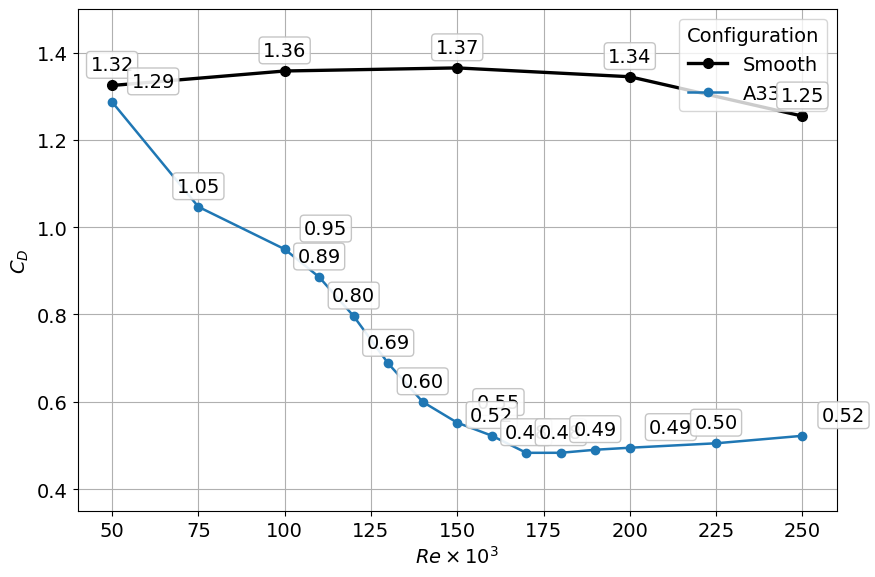

In [72]:
# Example: C_D vs Re for clean cylinder and the 0.94 mm trip wire.
# Edit angles as needed.
plot_cd_vs_re(
    results_df,
    trip_mm=[0.94,],
    include_clean=True,
    angles=[33],
    annotate=False,
    ylim=(0.35, 1.5),
    show_values = True,
    show_errorbars = False,
    show_title = False,
)


### For specific runs at different angles

In [12]:
selected_mask = (
    (
        (results_df["case"] == "Trip")
        & np.isclose(results_df["trip_mm"], 0.15)
        & results_df["angle"].isin([57, 63, 69])
    )
    |
    (
        (results_df["case"] == "Trip")
        & np.isclose(results_df["trip_mm"], 0.94)
        & results_df["angle"].isin([27, 33])
    )
)

selected_df = results_df[selected_mask].copy()
selected_mask = (
    (
        (results_df["case"] == "Trip")
        & np.isclose(results_df["trip_mm"], 0.15)
        & results_df["angle"].isin([57, 63, 69])
    )
    |
    (
        (results_df["case"] == "Trip")
        & np.isclose(results_df["trip_mm"], 0.94)
        & results_df["angle"].isin([27, 33])
    )
)

selected_df = results_df[selected_mask].copy()


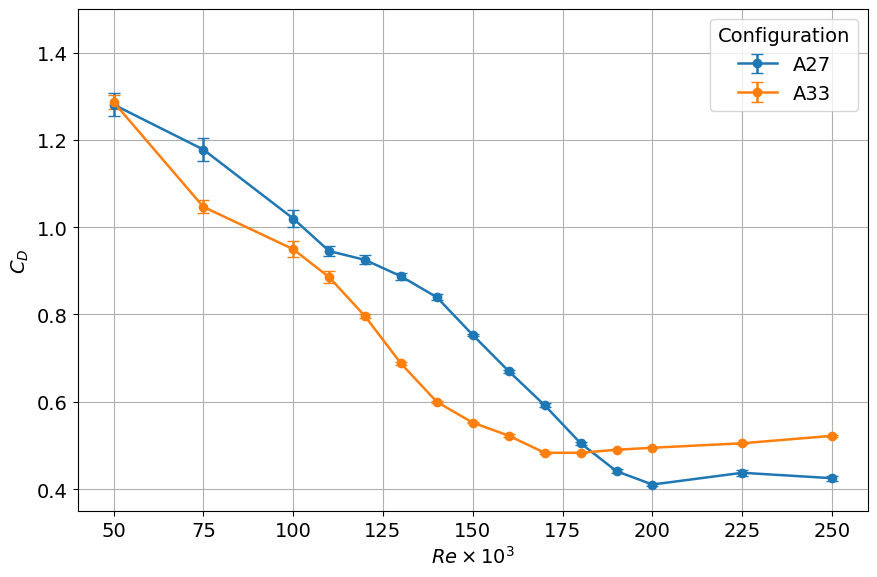

In [13]:
plot_cd_vs_re(
    selected_df,
    trip_mm=[0.15, 0.94],
    include_clean=False,
    angles=None,
    show_errorbars=True,
    show_values=False,
    show_title=False,
    ylim=(0.35, 1.5),
)


### $C_L$ plot 

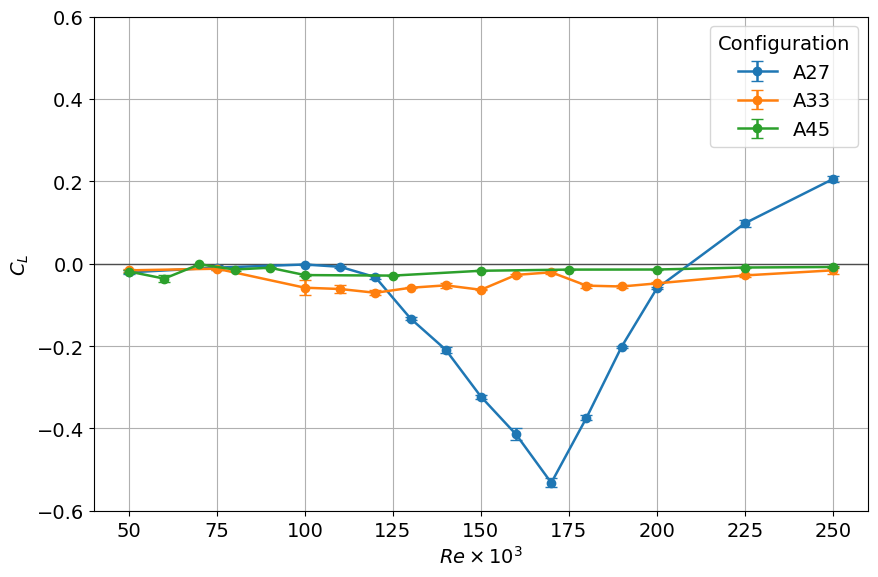

In [14]:
# Example: C_L vs Re.
plot_cl_vs_re(
    results_df,
    trip_mm=0.94,
    include_clean=False,
    angles=[27,33,45],
    ylim=(-0.6, 0.6),
    show_values = False,
    show_errorbars = True,
    show_title = False,
)


### $St$ plot (5 segments)

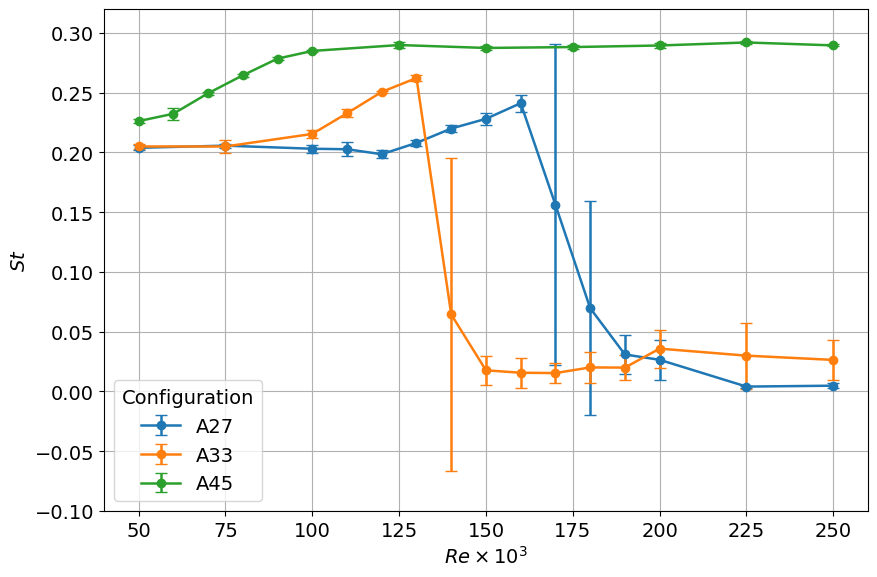

In [15]:
# Example: Strouhal number vs Re.
plot_st_vs_re(
    results_df,
    include_clean=False,
    angles=[27,33,45],
    ylim=(-0.1, 0.32),
    show_errorbars=True,
    show_values=False,
    show_title=False,
)


### $St$ vs Re, 1 segment

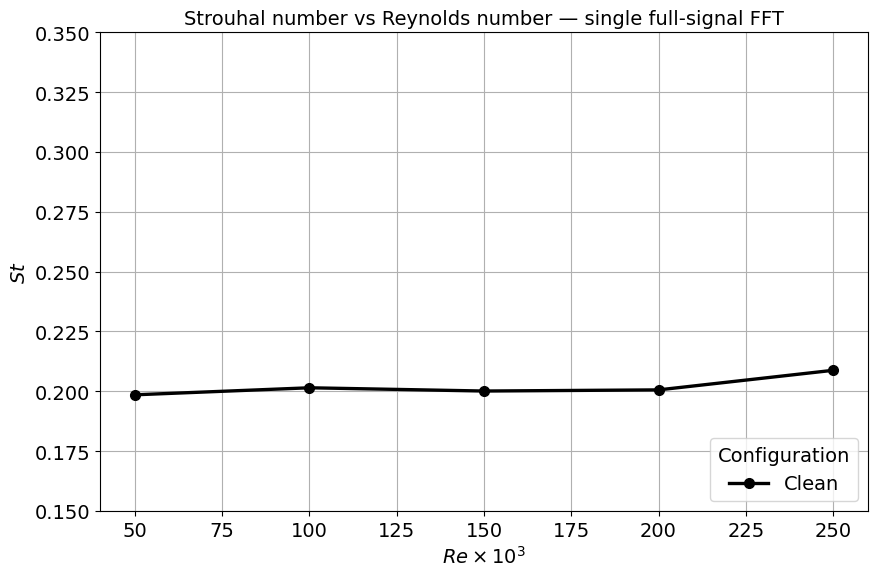

In [16]:
plot_single_st_vs_re(
    results_df,
    include_clean=True,
    angles=[],
    ylim=(0.15, 0.35)
)


### $Lift$ and $FFT$ plot 

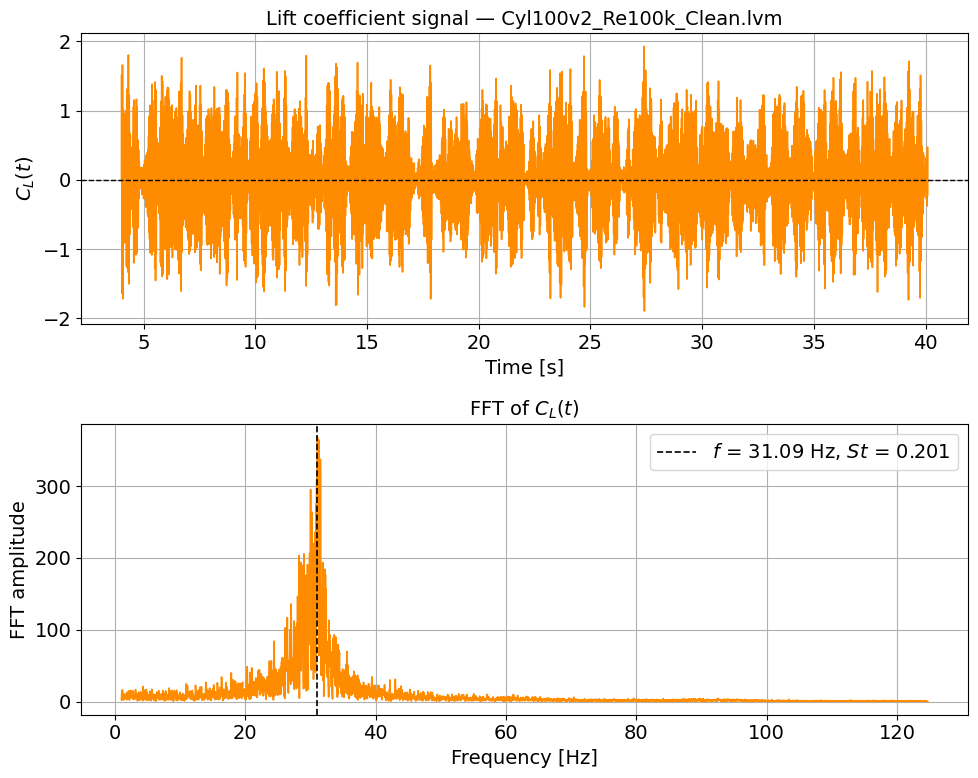

In [17]:
plot_lift_signal_and_fft(("Clean",), "Re100k")


### $Lift$ and $FFT$ 5 segments

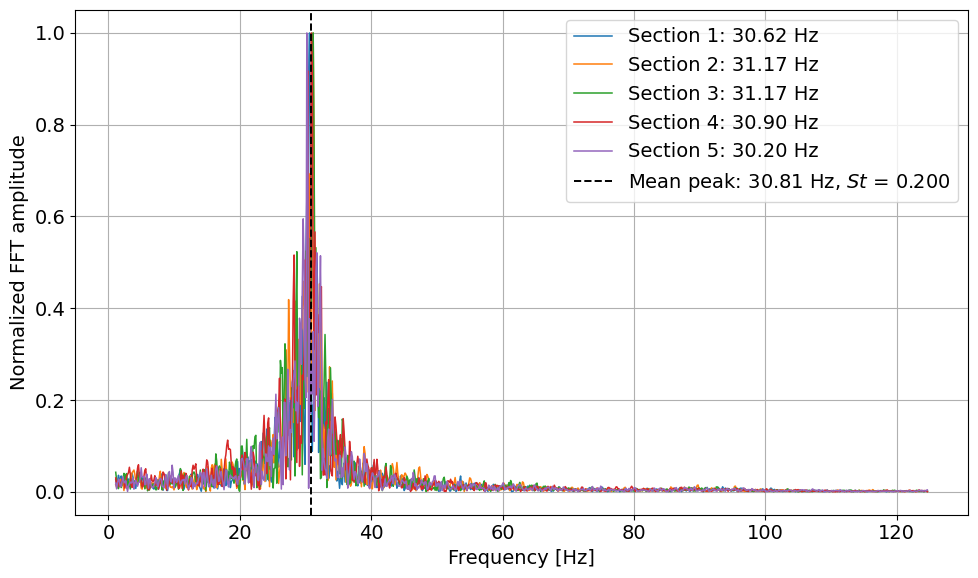

Dominant frequencies by section [Hz]:
Section 1: 30.618 Hz
Section 2: 31.173 Hz
Section 3: 31.173 Hz
Section 4: 30.897 Hz
Section 5: 30.203 Hz

Mean frequency: 30.813 Hz
Mean Strouhal number: 0.1996


In [18]:
plot_lift_fft_segments(("Clean",), "Re100k", n_segments=5,show_title=False)


### $C_P$ distribution plot 

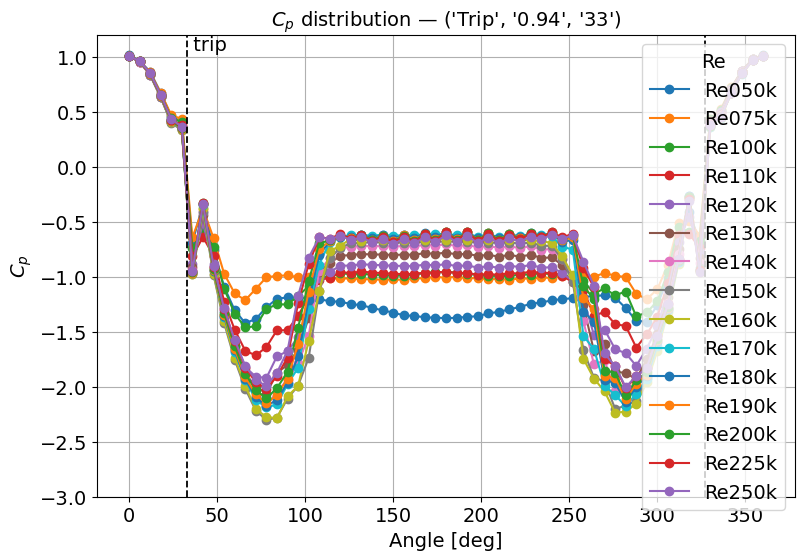

In [19]:
# Example: Cp distribution for one group.
# For clean:
# plot_cp_distribution(("Clean",), target_re=None, ylim=(-3.0, 1.2), show_title=False)
# For trip wire, uncomment and edit:
plot_cp_distribution(("Trip", "0.94", "33"), target_re=None, ylim=(-3.0, 1.2),)


### $C_P$ angular-sweep plots

Use these when one Reynolds number contains many trip-wire angles. The first plot type shows the full sweep in grey with selected cases highlighted; the second shows only the selected cases for clean interpretation.


Smooth reference not found for Re080k; skipping it.
Smooth reference not found for Re090k; skipping it.


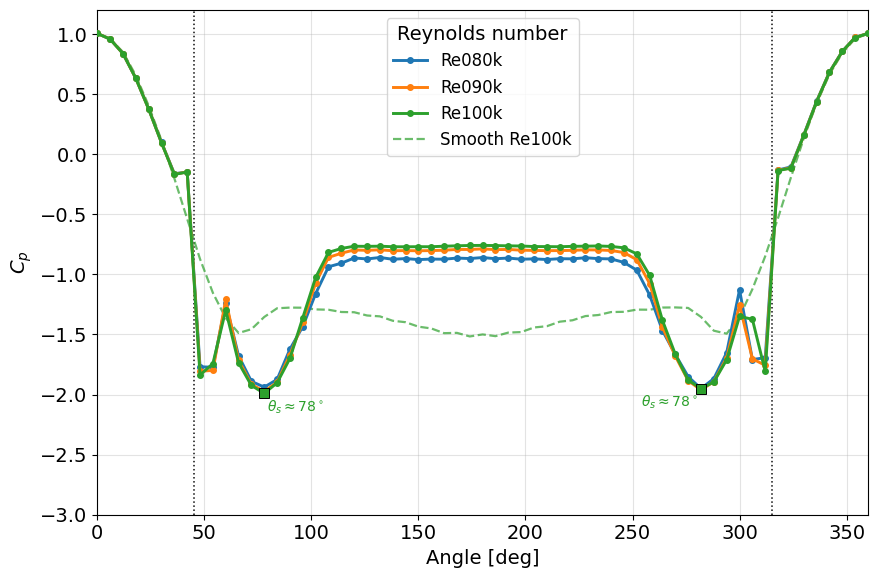

,re,trip_mm,angle,C_D,C_L,St
8,Re080k,0.94,45.0,0.734416,-0.014195,0.264502
9,Re090k,0.94,45.0,0.651143,-0.009838,0.278476
13,Re100k,0.94,45.0,0.620080,-0.027720,0.284897


In [70]:
# ============================================================
# Example calls: Cp angular sweep and Reynolds sweep
# ============================================================
# These examples are intentionally commented out so "Run all" does not fail
# if a particular Reynolds number or angle is not present in your data folder.

# -------------------------
# 1) Angular sweep: fixed Re, varying trip-wire angle
# -------------------------
# highlighted_angles = [27, 33, 39, 45]
# plot_cp_angular_sweep(
#     target_re="Re140k",
#     trip_mm=0.94,
#     highlight_angles=highlighted_angles,
#     mode="both",          # "overview", "selected", or "both"
#     ylim=(-3.0, 1.2),
#     show_title=False,
# )

# -------------------------
# 2) Reynolds sweep: fixed trip-wire angle, varying Re
# -------------------------
plot_cp_re_sweep(
    target_angle=45,
    trip_mm=0.94,
    reynolds_list=["Re080k","Re090k","Re100k",],
    include_smooth=True,  # set True to add dashed smooth reference curves
    marker_every=1,        # marker at every pressure tap
    ylim=(-3.0, 1.2),
    show_title=False,
    show_separation_points=True,  # mark Cp-based separation estimates and label theta_s
    separation_marker_for=["Re100k",],
    separation_label_offset_points=(2, -16)
)


### Variance and RMS

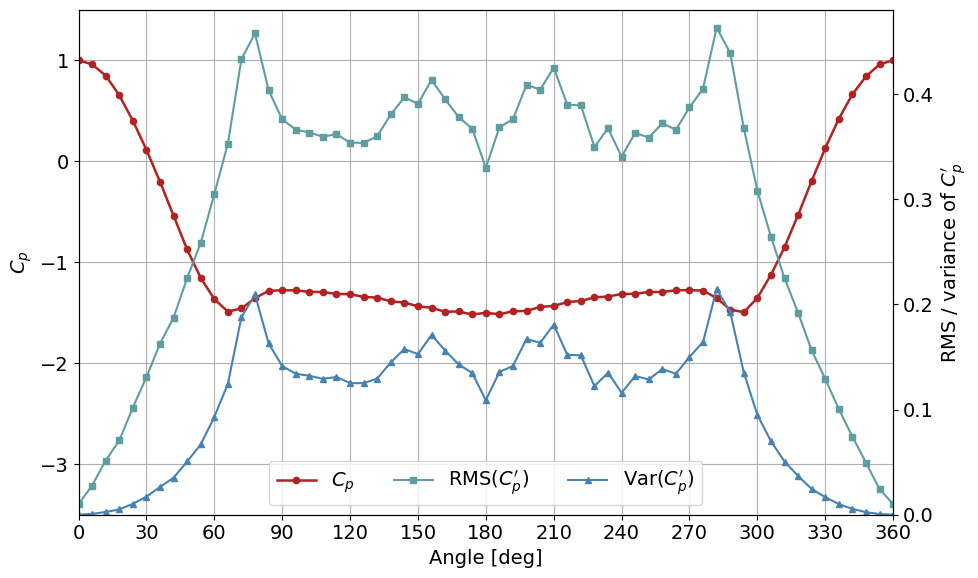

In [21]:
plot_cp_rms_variance(("Clean",), "Re100k", ylim_cp=(-3.5, 1.5), ylim_stats=(0, 0.48), show_title=False)


# All plots
# for run in get_runs(("Clean",)):
#     plot_cp_rms_variance(("Clean",), run["re"])


### $C_P$ around the cylinder plot 

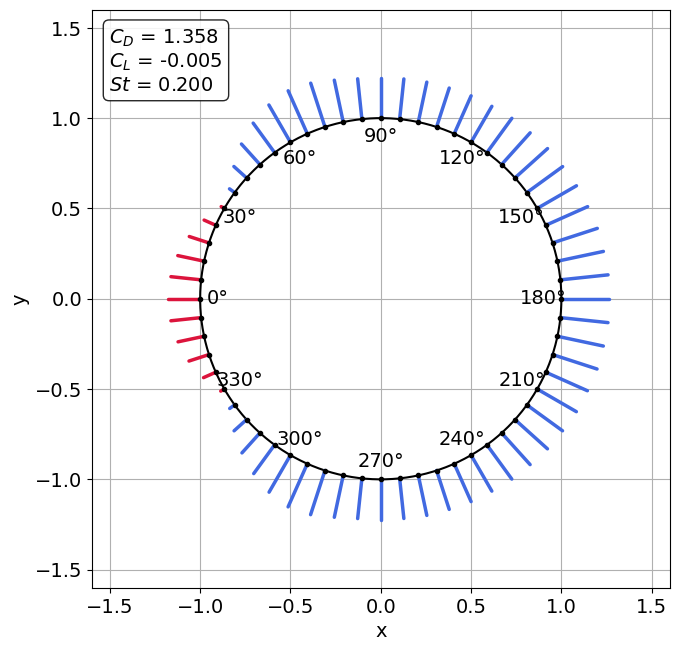

In [22]:
# Example: normal-bar plot for one run.
# Fixed cp_abs_max makes plots comparable across cases.
plot_cp_normal_bars(
    target_key=("Clean",),
    target_re="Re100k",
    cp_abs_max=2.0,
    use_magnitude=True,
    show_title=False,
)

# For a trip-wire case, uncomment and edit:
# plot_cp_normal_bars(
#     target_key=("Trip", "0.94", "27"),
#     target_re="Re100k",
#     cp_abs_max=2.0,
#     use_magnitude=True,
# )


### $C_P$ around the cylinder comparison plot 

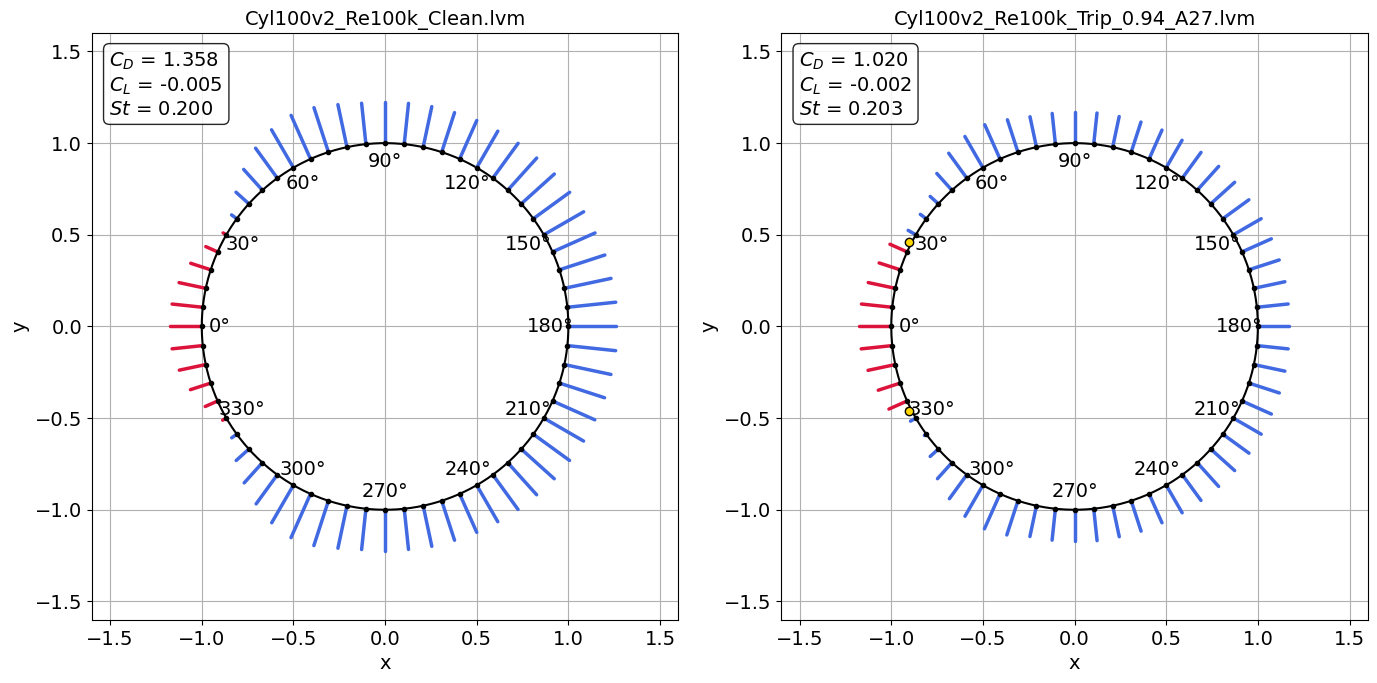

In [23]:
# Example: compare clean and trip side by side.
# Requires the selected trip case to exist in DATA_FOLDER.
compare_cp_normal_bars(
    target_key_1=("Clean",),
    target_re_1="Re100k",
    target_key_2=("Trip", "0.94", "27"),
    target_re_2="Re100k",
    cp_abs_max=2.0,
    use_magnitude=True,
)


### $Uncertaincy$ plot 

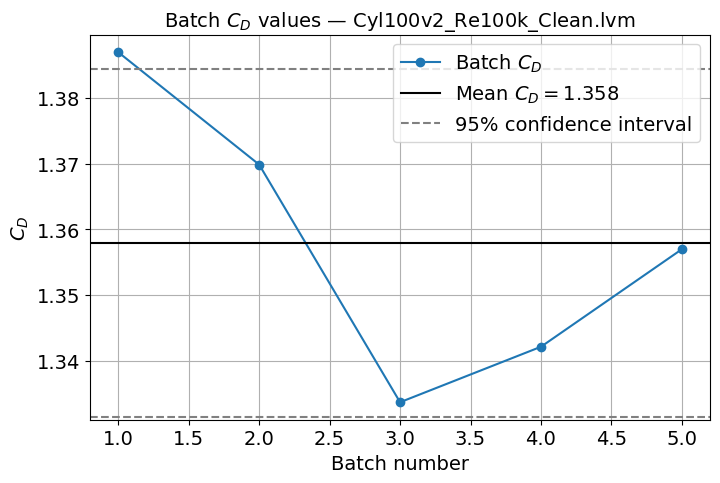

C_D = 1.3579 ± 0.0264
Batch 1: C_D = 1.3869
Batch 2: C_D = 1.3698
Batch 3: C_D = 1.3338
Batch 4: C_D = 1.3422
Batch 5: C_D = 1.3570


In [24]:
# Example: batch uncertainty plot for one run.
plot_batch_cd(("Clean",), "Re100k")


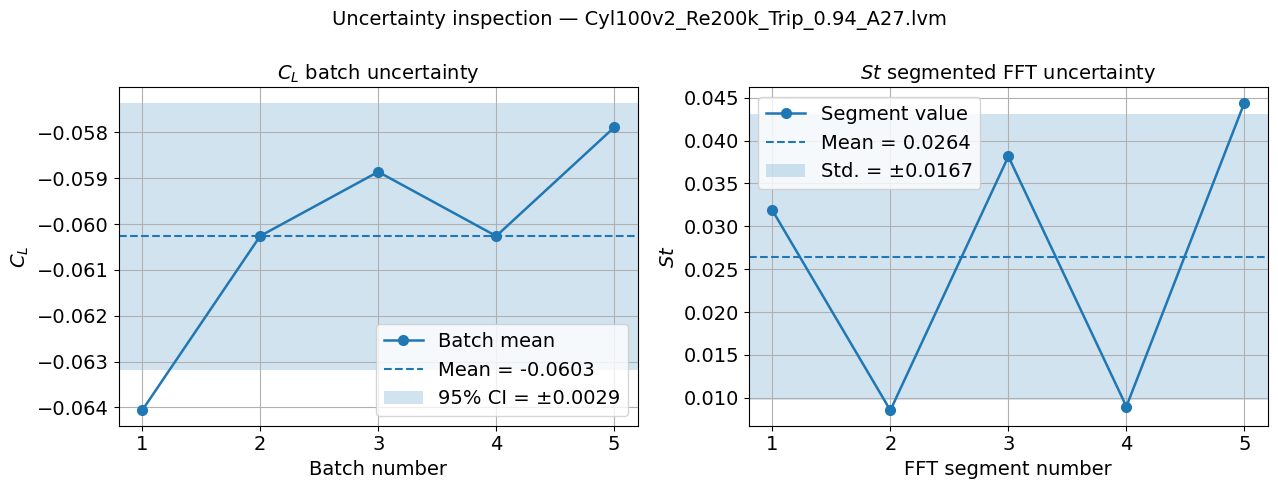

Cyl100v2_Re200k_Trip_0.94_A27.lvm

C_L batch values:


,batch,C_L_mean
0,1,-0.064065
1,2,-0.060260
2,3,-0.058860
3,4,-0.060261
4,5,-0.057889


C_L mean:     -0.06027
C_L std:      0.00235
C_L 95% CI:   ±0.00292

St segment values:


,segment,f_shedding,U_mean,St
0,1,9.836793,30.864745,0.031871
1,2,2.632334,30.875888,0.008526
2,3,11.776425,30.864627,0.038155
3,4,2.770757,30.878009,0.008973
4,5,13.716648,30.877164,0.044423


St mean:      0.02639
St std:       0.01670


(   batch  C_L_mean
 0      1 -0.064065
 1      2 -0.060260
 2      3 -0.058860
 3      4 -0.060261
 4      5 -0.057889,
    segment  f_shedding     U_mean        St
 0        1    9.836793  30.864745  0.031871
 1        2    2.632334  30.875888  0.008526
 2        3   11.776425  30.864627  0.038155
 3        4    2.770757  30.878009  0.008973
 4        5   13.716648  30.877164  0.044423)

In [25]:
plot_cl_st_uncertainty_batches(("Trip", "0.94", "27"), "Re200k")


### Specific inspection

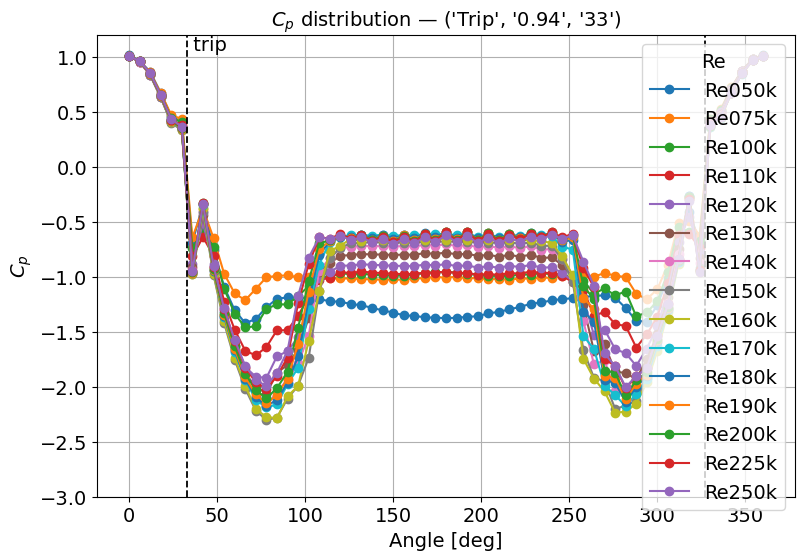

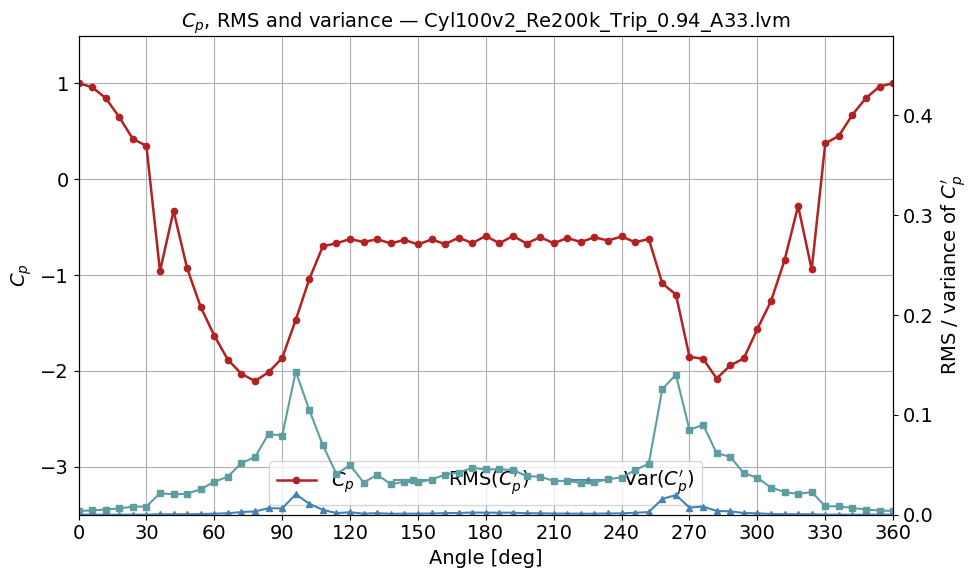

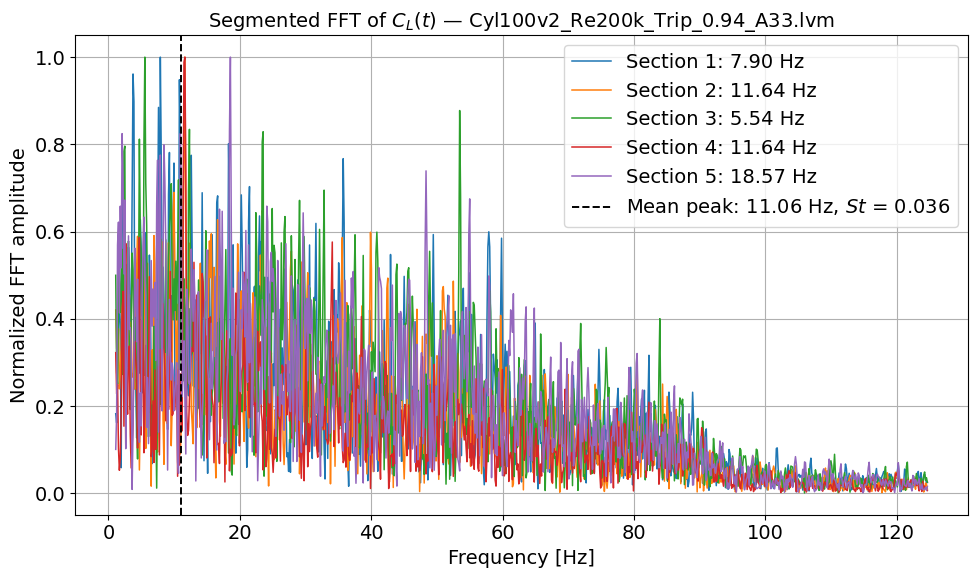

Dominant frequencies by section [Hz]:
Section 1: 7.897 Hz
Section 2: 11.638 Hz
Section 3: 5.542 Hz
Section 4: 11.637 Hz
Section 5: 18.566 Hz

Mean frequency: 11.056 Hz
Mean Strouhal number: 0.0357


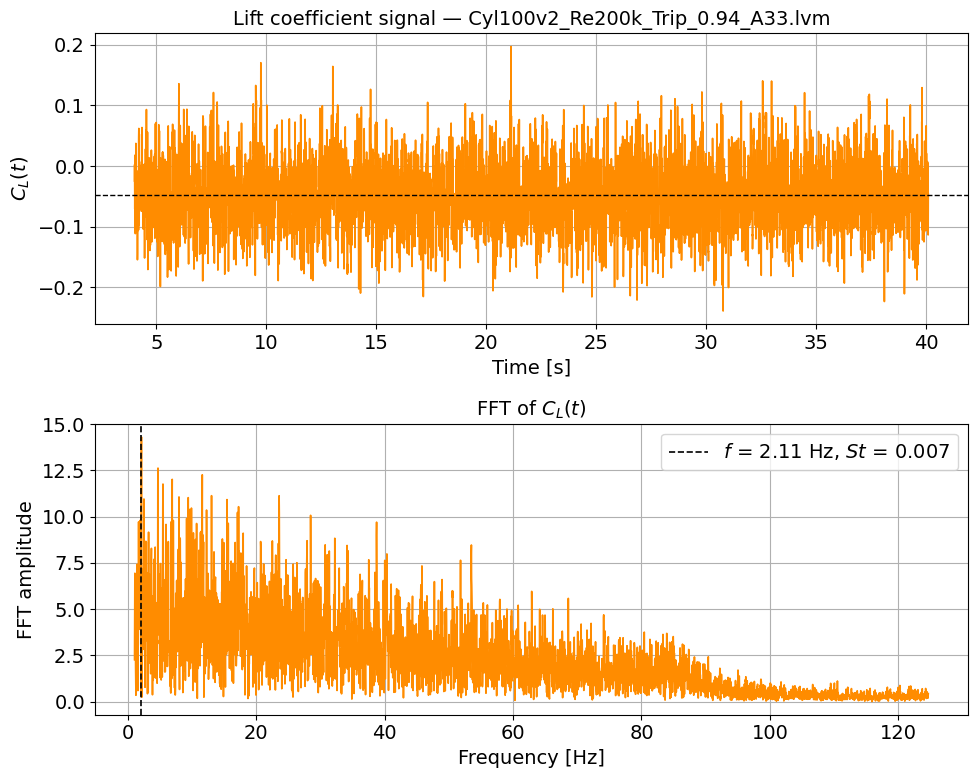

In [26]:
plot_cp_distribution(("Trip", "0.94", "33"))
plot_cp_rms_variance(("Trip", "0.94", "33"), "Re200k", ylim_cp=(-3.5, 1.5), ylim_stats=(0, 0.48))
plot_lift_fft_segments(("Trip", "0.94", "33"), "Re200k", n_segments=5)
plot_lift_signal_and_fft(("Trip", "0.94", "33"), "Re200k")


## 7. Inspect extra channels

In [27]:
def summarize_extra_channels(target_key=None, target_re=None):
    """
    Summarize pitot, tunnel velocity, density, time, etc.

    target_key=None gives all runs.
    """
    selected_runs = runs

    if target_key is not None:
        selected_runs = get_runs(target_key, target_re=target_re)

    rows = []

    for run in selected_runs:
        extra = run["extra_data"]

        for col in EXTRA_NAMES:
            s = extra[col]
            rows.append({
                "file": run["file_name"],
                "re": run["re"],
                "case": run["case"],
                "trip_mm": run["trip_mm"],
                "angle": run["angle"],
                "variable": col,
                "mean": s.mean(),
                "std": s.std(),
                "min": s.min(),
                "max": s.max(),
            })

    return pd.DataFrame(rows)


extra_summary = summarize_extra_channels()
display(extra_summary.head(20))


,file,re,case,trip_mm,angle,variable,mean,std,min,max
0,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,pitot,35.753948,7.679387e-01,30.664125,41.342487
1,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,AoA,0.001000,4.337026e-19,0.001000,0.001000
2,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,F,-0.218186,2.745563e-02,-0.355432,-0.099042
3,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,alpha,0.046792,2.007344e-01,-0.292469,0.440362
4,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,P_m,35.754835,1.249446e-01,35.414814,36.147964
5,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,V_tunnel,7.832404,1.368166e-02,7.795085,7.875358
6,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,rho,1.165664,2.220557e-16,1.165664,1.165664
7,Cyl100v2_Re050k_Clean.lvm,Re050k,Clean,NaN,NaN,time,20.047885,1.157569e+01,-0.000021,40.095122
8,Cyl100v2_Re050k_Trip_0.94_A27.lvm,Re050k,Trip,0.94,27.0,pitot,34.862855,7.302419e-01,29.986866,41.713993
9,Cyl100v2_Re050k_Trip_0.94_A27.lvm,Re050k,Trip,0.94,27.0,AoA,0.001000,4.337026e-19,0.001000,0.001000


In [28]:
# Optional: plot one extra channel across all runs.
def plot_extra_channel(channel="pitot", target_key=None, show_title=True):
    selected_runs = runs if target_key is None else get_runs(target_key)

    fig, ax = plt.subplots(figsize=(10, 5))

    for run in selected_runs:
        ax.plot(
            run["extra_data"].index,
            run["extra_data"][channel],
            label=run["file_name"],
            alpha=0.9,
        )

    ax.set_xlabel("Sample number")
    ax.set_ylabel(channel)
    if show_title:
        ax.set_title(f"{channel} across selected files")
    ax.grid(True)
    ax.legend()
    plt.show()


# Example:
# plot_extra_channel("pitot")
# plot_extra_channel("V_tunnel", target_key=("Clean",))


## 8. Notes

Important assumptions in this notebook:

1. The dynamic pressure channel is column 64 in 1-based indexing, i.e. Python index `63`.
2. Layer 1 is interpreted as the taps at \(0^\circ, 12^\circ, \ldots, 348^\circ\).
3. Layer 2 is interpreted as the taps at \(6^\circ, 18^\circ, \ldots, 354^\circ\).
4. \(C_D\) and \(C_L\) use the same sign convention as your previous working notebook.
5. The Strouhal number is computed from the time-resolved \(C_L(t)\) signal. This is often more robust than using a single pressure tap, but it may differ slightly from Gamst's tap-based method.

If you want strict consistency with Gamst's method, the next useful addition would be a second Strouhal calculation based on a chosen pressure tap, for example tap 24 / approximately \(138^\circ\), and then comparing it against the \(C_L(t)\)-based value.


In [29]:
# In the Day 2 notebook, run:

results_day2 = results_df.copy()
results_day2["test_day"] = "Day 2"
results_day2.to_csv("results_day2.csv", index=False)



## CFD comparison — Strouhal number overlay

This section reads STAR-CCM+ monitor CSV files using a domain-aware naming convention:

- `WT_Smooth_CL.csv`, `WT_27deg_CL.csv`, ...
- `LD_Smooth_CL.csv`, `LD_27deg_CL.csv`, ... when the large-domain results are available.

The dominant frequency is extracted from the monitor signal and converted to

\[
St = \frac{fD}{U_\infty}.
\]

The Reynolds number and velocity are not stored in the CSV files, so they are supplied in `CFD_DOMAINS`. Missing files are skipped automatically, so the same notebook can be used before and after the LD results are added.


In [30]:

# ============================================================
# CFD Strouhal extraction from STAR-CCM+ monitor CSV files
# Domain-aware version: WT_* now, LD_* later
# ============================================================
# Expected naming convention:
#   WT_Smooth_CL.csv, WT_27deg_CL.csv, WT_33deg_CL.csv, WT_45deg_CL.csv
#   LD_Smooth_CL.csv, LD_27deg_CL.csv, LD_33deg_CL.csv, LD_45deg_CL.csv   # optional/future
#
# IMPORTANT:
# - Re is used for the x-axis.
# - D and U_inf are used to compute St = fD/U_inf.
# - If U_inf is None, U_inf = Re * nu / D is used.
# - The default Re=200000 is only a placeholder. Change it if the CFD runs use another Re.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

# Folder containing the STAR-CCM+ monitor CSVs.
# Usually this can stay as Path.cwd() when the CSVs are in the same folder as the notebook.
CFD_MONITOR_FOLDER = Path.cwd()

# Default metadata for CFD cases.
CFD_DEFAULT_D = D if "D" in globals() else 0.100       # [m]
CFD_DEFAULT_NU = 1.50e-5                              # [m^2/s], adjust if needed
CFD_DEFAULT_RE = 200000                               # placeholder; change if needed

# FFT extraction settings for the CFD monitor signals.
CFD_REMOVE_FIRST_FRAC = 0.10
CFD_F_MIN = 1.0
CFD_F_MAX = 500.0

# Domains to include. Keep WT active now. Add LD files later and the same code will pick them up.
# You can set a different Re/U_inf for WT and LD if needed.
CFD_DOMAINS = [
    {"domain": "WT", "domain_label": "WT CFD", "prefix": "WT",
     "Re": CFD_DEFAULT_RE, "D": CFD_DEFAULT_D, "U_inf": None, "nu": CFD_DEFAULT_NU},

    # Future large-domain cases. These are skipped automatically until the files exist.
    {"domain": "LD", "domain_label": "LD CFD", "prefix": "LD",
     "Re": CFD_DEFAULT_RE, "D": CFD_DEFAULT_D, "U_inf": None, "nu": CFD_DEFAULT_NU},
]

CFD_CASES = [
    {"case": "Clean", "angle": np.nan, "name": "Smooth", "label_suffix": "smooth"},
    {"case": "Trip",  "angle": 27,     "name": "27deg",  "label_suffix": "A27"},
    {"case": "Trip",  "angle": 33,     "name": "33deg",  "label_suffix": "A33"},
    {"case": "Trip",  "angle": 45,     "name": "45deg",  "label_suffix": "A45"},
]


def make_cfd_cl_runs(domains=CFD_DOMAINS, cases=CFD_CASES):
    """Create CFD_RUNS from the domain/case naming convention."""
    runs = []
    for domain in domains:
        for case in cases:
            runs.append({
                "domain": domain["domain"],
                "domain_label": domain["domain_label"],
                "label": f'{domain["domain_label"]} {case["label_suffix"]}',
                "file": f'{domain["prefix"]}_{case["name"]}_CL.csv',
                "case": case["case"],
                "angle": case["angle"],
                "Re": domain.get("Re", CFD_DEFAULT_RE),
                "D": domain.get("D", CFD_DEFAULT_D),
                "U_inf": domain.get("U_inf", None),
                "nu": domain.get("nu", CFD_DEFAULT_NU),
            })
    return runs


# Editable metadata for the CFD monitor files.
# Modify this list manually if a single case has a different file name, Re, D, U_inf, etc.
CFD_RUNS = make_cfd_cl_runs()


In [31]:

def resolve_optional_cfd_monitor_path(file_name, folder=CFD_MONITOR_FOLDER):
    """Return a file path if it exists; otherwise return None."""
    if file_name is None or (isinstance(file_name, float) and np.isnan(file_name)):
        return None

    candidates = [
        Path(file_name),
        folder / file_name,
        Path.cwd() / file_name,
        Path("/mnt/data") / file_name,  # useful in this environment; harmless locally
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def read_starccm_monitor_csv(file_path):
    """
    Read a STAR-CCM+ monitor CSV.

    Expected format:
        Time, monitor value

    The second column can be named CL Monitor, Cd Monitor, etc.
    """
    df = pd.read_csv(file_path)
    if df.shape[1] < 2:
        raise ValueError(f"{file_path} must contain at least two columns: time and monitor value.")

    time = pd.to_numeric(df.iloc[:, 0], errors="coerce").to_numpy(dtype=float)
    signal = pd.to_numeric(df.iloc[:, 1], errors="coerce").to_numpy(dtype=float)

    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    order = np.argsort(time)
    time = time[order]
    signal = signal[order]

    # Remove duplicate time values if present.
    unique_time, unique_idx = np.unique(time, return_index=True)
    time = unique_time
    signal = signal[unique_idx]

    if len(time) < 20:
        raise ValueError(f"{file_path} contains too few valid samples after cleaning.")

    return time, signal, list(df.columns)


def parabolic_peak_refinement(freqs, amplitude, peak_idx):
    """
    Refine the FFT-bin frequency estimate using parabolic interpolation around the peak.
    This is useful because the monitor files are short, so FFT-bin spacing can be coarse.
    """
    if peak_idx <= 0 or peak_idx >= len(amplitude) - 1:
        return freqs[peak_idx]

    y0 = np.log(max(amplitude[peak_idx - 1], 1e-300))
    y1 = np.log(max(amplitude[peak_idx],     1e-300))
    y2 = np.log(max(amplitude[peak_idx + 1], 1e-300))

    denom = y0 - 2*y1 + y2
    if abs(denom) < 1e-14:
        return freqs[peak_idx]

    delta = 0.5 * (y0 - y2) / denom
    delta = np.clip(delta, -1.0, 1.0)
    return freqs[peak_idx] + delta * (freqs[1] - freqs[0])


def estimate_cfd_dominant_frequency(time,
                                    signal,
                                    remove_first_frac=CFD_REMOVE_FIRST_FRAC,
                                    f_min=CFD_F_MIN,
                                    f_max=CFD_F_MAX):
    """
    Estimate the dominant frequency of a CFD monitor signal using a Hann-windowed FFT.

    Returns a dictionary containing the dominant frequency and diagnostic arrays.
    """
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    start = int(len(time) * remove_first_frac)
    time = time[start:]
    signal = signal[start:]

    if len(time) < 20:
        raise ValueError("Too few samples after removing transient.")

    dt = np.median(np.diff(time))
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Invalid time step in CFD monitor file.")

    fs = 1.0 / dt
    nyquist = 0.5 * fs
    f_max_eff = min(float(f_max), 0.98 * nyquist)

    signal = signal - np.nanmean(signal)
    window = np.hanning(len(signal))
    fft_vals = np.fft.rfft(signal * window)
    freqs = np.fft.rfftfreq(len(signal), d=dt)
    amp = np.abs(fft_vals)

    # Remove zero frequency and apply search band.
    freqs = freqs[1:]
    amp = amp[1:]
    band = (freqs >= f_min) & (freqs <= f_max_eff)

    if not np.any(band):
        raise ValueError(f"No FFT frequencies inside selected band {f_min}–{f_max_eff} Hz.")

    freqs_band = freqs[band]
    amp_band = amp[band]
    peak_idx = int(np.argmax(amp_band))
    f_raw = float(freqs_band[peak_idx])
    f_refined = float(parabolic_peak_refinement(freqs_band, amp_band, peak_idx))

    # Simple peak-strength diagnostic: peak divided by median band amplitude.
    median_amp = np.nanmedian(amp_band)
    peak_strength = float(amp_band[peak_idx] / median_amp) if median_amp > 0 else np.nan

    return {
        "f_Hz": f_refined,
        "f_raw_Hz": f_raw,
        "freqs": freqs_band,
        "amplitude": amp_band,
        "peak_strength": peak_strength,
        "sampling_frequency_Hz": fs,
        "dt": dt,
        "n_samples_used": len(time),
        "search_f_min_Hz": f_min,
        "search_f_max_Hz": f_max_eff,
    }


def build_cfd_st_dataframe(cfd_runs=CFD_RUNS):
    """
    Build a dataframe with CFD Strouhal values from STAR-CCM+ monitor CSV files.

    Missing files are skipped. This lets the notebook work with WT files now and LD files later.
    """
    rows = []

    for run in cfd_runs:
        path = resolve_optional_cfd_monitor_path(run["file"])

        row_base = {
            "domain": run.get("domain", ""),
            "domain_label": run.get("domain_label", ""),
            "label": run["label"],
            "file": run["file"],
            "case": run["case"],
            "angle": run.get("angle", np.nan),
            "warning": "",
        }

        if path is None:
            skipped = row_base.copy()
            skipped.update({
                "Re": float(run.get("Re", CFD_DEFAULT_RE)),
                "re": "",
                "D_m": float(run.get("D", CFD_DEFAULT_D)),
                "U_inf_m_s": np.nan,
                "nu_m2_s": float(run.get("nu", CFD_DEFAULT_NU)),
                "f_Hz": np.nan,
                "f_raw_Hz": np.nan,
                "St": np.nan,
                "monitor_column": "",
                "peak_strength": np.nan,
                "sampling_frequency_Hz": np.nan,
                "n_samples_used": 0,
                "warning": f"File {run['file']!r} not found. Skipped.",
                "_time": np.array([]),
                "_signal": np.array([]),
                "_freq_info": {},
            })
            rows.append(skipped)
            continue

        time, signal, columns = read_starccm_monitor_csv(path)

        D_cfd = float(run.get("D", CFD_DEFAULT_D))
        Re_cfd = float(run.get("Re", CFD_DEFAULT_RE)) if run.get("Re") is not None else np.nan
        nu_cfd = float(run.get("nu", CFD_DEFAULT_NU))
        U_inf = run.get("U_inf", None)

        if U_inf is None:
            if not np.isfinite(Re_cfd):
                raise ValueError(f"Either Re or U_inf must be supplied for {run['label']}.")
            U_inf = Re_cfd * nu_cfd / D_cfd
        else:
            U_inf = float(U_inf)
            if not np.isfinite(Re_cfd):
                Re_cfd = U_inf * D_cfd / nu_cfd

        freq_info = estimate_cfd_dominant_frequency(time, signal)
        f_Hz = freq_info["f_Hz"]
        St = f_Hz * D_cfd / U_inf

        monitor_name = columns[1] if len(columns) > 1 else "monitor"
        monitor_warning = ""
        if "cd" in monitor_name.lower():
            monitor_warning = "Second column appears to be Cd, not CL. Interpret frequency with caution."

        row = row_base.copy()
        row.update({
            "file": path.name,
            "Re": Re_cfd,
            "re": f"Re{int(round(Re_cfd / 1000))}k" if np.isfinite(Re_cfd) else "",
            "D_m": D_cfd,
            "U_inf_m_s": U_inf,
            "nu_m2_s": nu_cfd,
            "f_Hz": f_Hz,
            "f_raw_Hz": freq_info["f_raw_Hz"],
            "St": St,
            "monitor_column": monitor_name,
            "peak_strength": freq_info["peak_strength"],
            "sampling_frequency_Hz": freq_info["sampling_frequency_Hz"],
            "n_samples_used": freq_info["n_samples_used"],
            "warning": monitor_warning,
            "_time": time,
            "_signal": signal,
            "_freq_info": freq_info,
        })
        rows.append(row)

    return pd.DataFrame(rows)


cfd_st_df = build_cfd_st_dataframe()

# Display a clean summary table. Missing LD files are shown as skipped, but only finite St rows are plotted.
display_cols = [
    "domain", "label", "file", "monitor_column", "Re", "U_inf_m_s", "f_Hz", "St",
    "peak_strength", "warning"
]
display(cfd_st_df[display_cols])


,domain,label,file,monitor_column,Re,U_inf_m_s,f_Hz,St,peak_strength,warning
0,WT,WT CFD smooth,WT_Smooth_CL.csv,CL Monitor: CL Monitor,200000.0,30.0,23.658237,0.078861,1217.183643,
1,WT,WT CFD A27,WT_27deg_CL.csv,CL Monitor: CL Monitor,200000.0,30.0,15.173461,0.050578,826.529662,
2,WT,WT CFD A33,WT_33deg_CL.csv,CL Monitor: CL Monitor,200000.0,30.0,24.512775,0.081709,637.190180,
3,WT,WT CFD A45,WT_45deg_CL.csv,CL Monitor: CL Monitor,200000.0,30.0,17.051670,0.056839,582.501308,
4,LD,LD CFD smooth,LD_Smooth_CL.csv,CL Monitor: CL Monitor,200000.0,30.0,25.260596,0.084202,1272.358307,
5,LD,LD CFD A27,LD_27deg_CL.csv,CL Monitor: CL Monitor,200000.0,30.0,24.165743,0.080552,3939.799698,
6,LD,LD CFD A33,LD_33deg_CL.csv,CL Monitor: CL Monitor,200000.0,30.0,23.940991,0.079803,1904.470647,
7,LD,LD CFD A45,LD_45deg_CL.csv,CL Monitor: CL Monitor,200000.0,30.0,17.733633,0.059112,3436.927850,


In [32]:

# ============================================================
# Plot color helpers for CFD/experimental comparison plots
# ============================================================
def _lookup_angle_color(angle, angle_colors=None, default=None):
    """
    Return a color from a dictionary keyed by angle.

    Accepts keys such as 33, 33.0, "33", or "33deg".
    """
    if angle_colors is None or angle is None or (isinstance(angle, float) and np.isnan(angle)):
        return default

    try:
        angle_float = float(angle)
    except Exception:
        return default

    for key, value in angle_colors.items():
        try:
            key_float = float(str(key).replace("deg", "").replace("°", ""))
        except Exception:
            continue
        if np.isclose(angle_float, key_float):
            return value

    return default


def _experimental_series_color(case, angle=None, smooth_color="black", trip_color=None, angle_colors=None, default=None):
    """Resolve the line/marker color for an experimental series."""
    if case == "Clean":
        return smooth_color
    return _lookup_angle_color(angle, angle_colors, default=trip_color if trip_color is not None else default)


def _normalize_cfd_domains(cfd_domains_to_plot):
    """
    Normalize a domain selector for CFD plots.

    Accepted examples:
        cfd_domains_to_plot=None          -> show all available domains
        cfd_domains_to_plot="WT"          -> show only WT
        cfd_domains_to_plot=["WT", "LD"]  -> show WT and LD
        cfd_domains_to_plot="all"         -> show all available domains
    """
    if cfd_domains_to_plot is None:
        return None

    if isinstance(cfd_domains_to_plot, str):
        values = [cfd_domains_to_plot]
    else:
        values = list(cfd_domains_to_plot)

    normalized = {str(v).upper().strip() for v in values if str(v).strip()}
    if not normalized or "ALL" in normalized:
        return None
    return normalized


def _filter_cfd_domains(cfd_plot, cfd_domains_to_plot=None):
    """Filter a CFD results DataFrame by domain, e.g. WT, LD, or both."""
    domains = _normalize_cfd_domains(cfd_domains_to_plot)
    if domains is None or cfd_plot is None or cfd_plot.empty or "domain" not in cfd_plot.columns:
        return cfd_plot

    return cfd_plot[cfd_plot["domain"].astype(str).str.upper().isin(domains)]


def _lookup_domain_color(domain, domain_colors=None, default=None):
    """Return a color from a dictionary keyed by domain, e.g. {"WT": "black", "LD": "gray"}."""
    if domain_colors is None:
        return default
    domain = str(domain).upper()
    for key, value in domain_colors.items():
        if str(key).upper() == domain:
            return value
    return default


def _lookup_domain_angle_color(domain, angle, domain_angle_colors=None, default=None):
    """
    Return a domain- and angle-specific color.

    Accepted examples:
        cfd_domain_angle_colors={"WT": {33: "darkgoldenrod"}, "LD": {33: "saddlebrown"}}
        cfd_domain_angle_colors={("WT", 33): "darkgoldenrod", ("LD", 33): "saddlebrown"}
    """
    if domain_angle_colors is None:
        return default

    domain = str(domain).upper()

    try:
        angle_float = float(angle)
    except Exception:
        return default

    # Tuple-key style: {("WT", 33): "..."}
    for key, value in domain_angle_colors.items():
        if isinstance(key, tuple) and len(key) == 2:
            key_domain, key_angle = key
            try:
                key_angle_float = float(str(key_angle).replace("deg", "").replace("°", ""))
            except Exception:
                continue
            if str(key_domain).upper() == domain and np.isclose(angle_float, key_angle_float):
                return value

    # Nested style: {"WT": {33: "..."}}
    for key_domain, angle_map in domain_angle_colors.items():
        if isinstance(key_domain, tuple):
            continue
        if str(key_domain).upper() != domain:
            continue
        if isinstance(angle_map, dict):
            return _lookup_angle_color(angle_float, angle_map, default=default)

    return default


def _cfd_series_color(row,
                      smooth_color="black",
                      trip_color=None,
                      angle_colors=None,
                      domain_colors=None,
                      domain_smooth_colors=None,
                      domain_trip_colors=None,
                      domain_angle_colors=None,
                      default=None):
    """
    Resolve the marker/errorbar color for a CFD point.

    General options
    ---------------
    smooth_color : str
        Fallback color for CFD smooth/clean cases.
    trip_color : str or None
        Fallback color for all CFD trip cases.
    angle_colors : dict or None
        Angle-specific CFD colors independent of WT/LD, e.g. {33: "darkgoldenrod"}.

    Domain-specific options
    -----------------------
    domain_smooth_colors : dict or None
        Domain-specific smooth colors, e.g. {"WT": "black", "LD": "dimgray"}.
    domain_trip_colors : dict or None
        Domain-specific fallback trip colors, e.g. {"WT": "darkgoldenrod", "LD": "saddlebrown"}.
    domain_angle_colors : dict or None
        Domain- and angle-specific trip colors, e.g.
        {"WT": {33: "darkgoldenrod"}, "LD": {33: "saddlebrown"}}.

    Fine-grained overrides
    ----------------------
    domain_colors : dict or None
        Optional most-specific overrides. Supported keys include:
        - exact label strings, e.g. "WT CFD smooth"
        - tuple keys, e.g. ("WT", "Clean") or ("WT", 33)
        - strings, e.g. "WT Clean", "WT 33", "LD 45"
    """
    case = row.get("case", None)
    label = str(row.get("label", ""))
    domain = str(row.get("domain", "")).upper()
    angle = row.get("angle", np.nan)

    # Most specific overrides first.
    if domain_colors is not None:
        candidate_keys = [label]
        if case == "Clean":
            candidate_keys += [
                (domain, "Clean"),
                (domain, "smooth"),
                f"{domain} Clean",
                f"{domain} smooth",
                f"{domain} CFD smooth",
            ]
        else:
            try:
                a_int = int(round(float(angle)))
                candidate_keys += [
                    (domain, a_int),
                    f"{domain} {a_int}",
                    f"{domain} A{a_int}",
                    f"{domain} CFD {a_int}",
                    f"{domain} CFD A{a_int}",
                ]
            except Exception:
                pass

        for key in candidate_keys:
            if key in domain_colors:
                return domain_colors[key]

    if case == "Clean":
        domain_color = _lookup_domain_color(domain, domain_smooth_colors, default=None)
        if domain_color is not None:
            return domain_color
        return smooth_color

    domain_angle_color = _lookup_domain_angle_color(domain, angle, domain_angle_colors, default=None)
    if domain_angle_color is not None:
        return domain_angle_color

    color = _lookup_angle_color(angle, angle_colors, default=None)
    if color is not None:
        return color

    domain_trip_color = _lookup_domain_color(domain, domain_trip_colors, default=None)
    if domain_trip_color is not None:
        return domain_trip_color

    if trip_color is not None:
        return trip_color

    return default


def _add_color_kwargs(base_kwargs, color):
    """Add Matplotlib color kwargs only when a color is explicitly set."""
    if color is not None:
        base_kwargs.update({
            "color": color,
            "markerfacecolor": color,
            "ecolor": color,
        })
    return base_kwargs



def plot_cfd_monitor_diagnostics(cfd_df=None, labels=None, normalize=True):
    """
    Plot the CFD monitor signal and FFT spectrum for selected CFD cases.

    This is useful for checking whether the reported frequency is a clear peak or just a weak/noisy estimate.
    """
    if cfd_df is None:
        cfd_df = cfd_st_df

    if labels is not None:
        cfd_df = cfd_df[cfd_df["label"].isin(labels)]

    for _, row in cfd_df.iterrows():
        time = row["_time"]
        signal = row["_signal"]
        freq_info = row["_freq_info"]
        freqs = freq_info["freqs"]
        amp = freq_info["amplitude"].copy()

        if normalize and np.nanmax(amp) > 0:
            amp = amp / np.nanmax(amp)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(time, signal, linewidth=1.2)
        axes[0].set_xlabel("Time [s]")
        axes[0].set_ylabel("Monitor value")
        axes[0].set_title(f"{row['label']} monitor")
        axes[0].grid(True)

        axes[1].plot(freqs, amp, linewidth=1.4)
        axes[1].axvline(row["f_Hz"], color="black", linestyle="--", linewidth=1.2,
                        label=f"f = {row['f_Hz']:.2f} Hz, St = {row['St']:.3f}")
        axes[1].set_xlabel("Frequency [Hz]")
        axes[1].set_ylabel("Normalized amplitude" if normalize else "Amplitude")
        axes[1].set_title(f"{row['label']} FFT spectrum")
        axes[1].grid(True)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

def plot_st_vs_re_with_cfd(results_df,
                           cfd_df=None,
                           trip_mm=None,
                           include_clean=True,
                           angles=None,
                           st_column="St",
                           show_experimental_errorbars=False,
                           show_values=False,
                           value_fmt="{:.3f}",
                           ylim=None,
                           title="Strouhal number vs Reynolds number — experiment and CFD",
                           show_title=False,
                           # Label placement options
                           smooth_label_y_offset=8,
                           trip_label_y_offset=8,
                           cfd_label_y_offset=0,
                           cfd_label_x_offset=14,
                           # Color options
                           exp_smooth_color="black",
                           exp_trip_color=None,
                           exp_angle_colors=None,
                           cfd_smooth_color="black",
                           cfd_trip_color=None,
                           cfd_angle_colors=None,
                           cfd_domain_colors=None,
                           cfd_domains_to_plot=None,
                           cfd_domain_smooth_colors=None,
                           cfd_domain_trip_colors=None,
                           cfd_domain_angle_colors=None,
                           cfd_label_color="match"):
    """
    Overlay CFD Strouhal values on the experimental Strouhal-number plot.

    Color control examples
    ----------------------
    - Make WT/LD CFD smooth black and 33 degree CFD darkgoldenrod:
        cfd_smooth_color="black", cfd_angle_colors={33: "darkgoldenrod"}

    - Make the experimental 33 degree curve orange:
        exp_angle_colors={33: "orange"}

    - Show only WT CFD results:
        cfd_domains_to_plot="WT"

    - Show both WT and LD CFD results:
        cfd_domains_to_plot=["WT", "LD"]

    - Set domain-specific smooth colors:
        cfd_domain_smooth_colors={"WT": "black", "LD": "dimgray"}

    - Set domain- and angle-specific trip colors:
        cfd_domain_angle_colors={"WT": {33: "darkgoldenrod"}, "LD": {33: "saddlebrown"}}

    - Fine-grained domain overrides:
        cfd_domain_colors={("WT", "Clean"): "black", ("WT", 33): "darkgoldenrod"}

    Parameters
    ----------
    st_column : str
        Experimental Strouhal column to use. Use:
        - "St" for the current segmented FFT values.
        - "St_single" for the original full-signal FFT values.
    """
    if cfd_df is None:
        cfd_df = cfd_st_df

    if st_column not in results_df.columns:
        raise ValueError(f"{st_column!r} is not in results_df. Available columns: {list(results_df.columns)}")

    fig, ax = plt.subplots(figsize=(9, 6))

    # -------------------------
    # Experimental smooth case
    # -------------------------
    if include_clean:
        clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")
        clean_df = clean_df[np.isfinite(clean_df[st_column])]
        if not clean_df.empty:
            if show_experimental_errorbars and st_column == "St" and "St_std" in clean_df.columns:
                ax.errorbar(
                    re_axis_values(clean_df["Re"]), clean_df[st_column], yerr=clean_df["St_std"],
                    fmt="o-", color=exp_smooth_color, linewidth=2.4, markersize=7, capsize=4,
                    label="Exp. smooth",
                )
            else:
                ax.plot(
                    re_axis_values(clean_df["Re"]), clean_df[st_column], "o-",
                    color=exp_smooth_color, linewidth=2.4, markersize=7, label="Exp. smooth",
                )
            if show_values:
                add_value_labels(
                    ax, re_axis_values(clean_df["Re"]), clean_df[st_column],
                    fmt=value_fmt, y_offset=smooth_label_y_offset,
                    color=exp_smooth_color if exp_smooth_color is not None else "black",
                )

    # -------------------------
    # Experimental trip cases
    # -------------------------
    trip_df = results_df[results_df["case"] == "Trip"].copy()

    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    trip_df = trip_df[np.isfinite(trip_df[st_column])]
    show_wire_in_label = (not trip_df.empty) and trip_df["trip_mm"].nunique(dropna=True) > 1

    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")
        label = f"Exp. {wire_size:.2f} mm A{int(angle)}" if show_wire_in_label else f"Exp. A{int(angle)}"
        exp_color = _experimental_series_color(
            "Trip", angle,
            smooth_color=exp_smooth_color,
            trip_color=exp_trip_color,
            angle_colors=exp_angle_colors,
            default=None,
        )

        if show_experimental_errorbars and st_column == "St" and "St_std" in group.columns:
            kwargs = dict(fmt="o-", linewidth=1.8, markersize=6, capsize=4, label=label)
            if exp_color is not None:
                kwargs["color"] = exp_color
            ax.errorbar(re_axis_values(group["Re"]), group[st_column], yerr=group["St_std"], **kwargs)
        else:
            kwargs = dict(linewidth=1.8, markersize=6, label=label)
            if exp_color is not None:
                kwargs["color"] = exp_color
            ax.plot(re_axis_values(group["Re"]), group[st_column], "o-", **kwargs)

        if show_values:
            add_value_labels(
                ax, re_axis_values(group["Re"]), group[st_column],
                fmt=value_fmt, y_offset=trip_label_y_offset,
                color=exp_color if exp_color is not None else "black",
            )

    # -------------------------
    # CFD points
    # -------------------------
    if cfd_df is not None and not cfd_df.empty:
        cfd_plot = cfd_df.copy()
        cfd_plot = cfd_plot[np.isfinite(cfd_plot["St"])]
        cfd_plot = _filter_cfd_domains(cfd_plot, cfd_domains_to_plot)

        if not include_clean:
            cfd_plot = cfd_plot[cfd_plot["case"] != "Clean"]

        if angles is not None:
            cfd_plot = cfd_plot[(cfd_plot["case"] == "Clean") | (cfd_plot["angle"].isin(angles))]

        for cfd_i, (_, row) in enumerate(cfd_plot.iterrows()):
            cfd_color = _cfd_series_color(
                row,
                smooth_color=cfd_smooth_color,
                trip_color=cfd_trip_color,
                angle_colors=cfd_angle_colors,
                domain_colors=cfd_domain_colors,
                domain_smooth_colors=cfd_domain_smooth_colors,
                domain_trip_colors=cfd_domain_trip_colors,
                domain_angle_colors=cfd_domain_angle_colors,
                default=None,
            )

            yerr = None
            if "St_std" in cfd_plot.columns and np.isfinite(row.get("St_std", np.nan)):
                yerr = [[row["St_std"]], [row["St_std"]]]

            kwargs = dict(
                fmt="s", markersize=8, markeredgecolor="black", markeredgewidth=1.0,
                capsize=4, zorder=5, label=row["label"],
            )
            _add_color_kwargs(kwargs, cfd_color)

            ax.errorbar(re_axis_values([row["Re"]]), [row["St"]], yerr=yerr, **kwargs)

            if show_values:
                label_color = cfd_color if cfd_label_color == "match" else cfd_label_color
                add_value_labels(
                    ax, re_axis_values([row["Re"]]), [row["St"]],
                    fmt=value_fmt, y_offset=cfd_label_y_offset,
                    x_offset=(cfd_label_x_offset if cfd_i % 2 == 0 else -cfd_label_x_offset),
                    avoid_overlap=False,
                    color=label_color if label_color is not None else "black",
                )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("Strouhal number")

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration", loc="best", fontsize=FIG_FONT_SIZE-1)
    plt.tight_layout()
    plt.show()


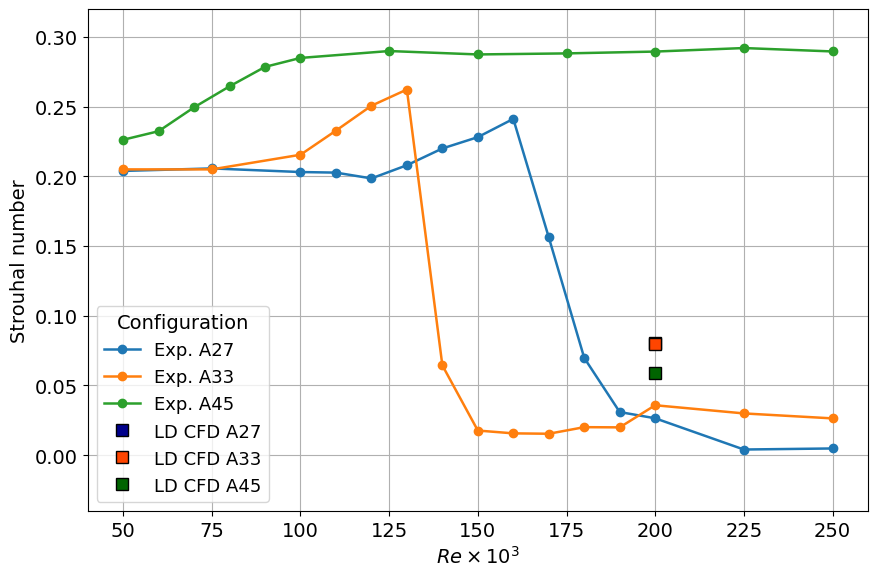

In [33]:
# Example: experimental 5-segment Strouhal values with WT/LD CFD monitor-derived values overlaid.
# Edit CFD_DEFAULT_RE / CFD_DOMAINS above if the CFD Reynolds number is not Re200k.
plot_st_vs_re_with_cfd(
    results_df,
    cfd_df=cfd_st_df[np.isfinite(cfd_st_df["St"])],
    include_clean=False,
    angles=[27, 33, 45],
    st_column="St",          # "St" = 5-segment experimental method; "St_single" = full-signal FFT
    ylim=(-0.04, 0.32),
    show_experimental_errorbars=False,
    show_values=False,
    show_title=False,
    exp_angle_colors={33: "tab:orange", 27: "tab:blue", 45: "tab:green"},

    # CFD domain display/color options:
    cfd_domains_to_plot=["LD",],   # use "WT", "LD", or ["WT", "LD"]
    cfd_domain_angle_colors={
        "WT": {33: "tab:orange", 27: "tab:blue", 45: "tab:green"},
        "LD": {33: "orangered", 27: "darkblue", 45: "darkgreen"},
    },
    cfd_domain_smooth_colors={"WT": "black", "LD": "dimgray"},
)



## CFD drag-coefficient comparison

This section overlays CFD mean drag coefficients on the experimental \(C_D\) vs \(Re\) plot.

It uses the same domain-aware naming convention:

- `WT_Smooth_CD.csv`, `WT_27deg_CD.csv`, ...
- `LD_Smooth_CD.csv`, `LD_27deg_CD.csv`, ... when the large-domain results are available.

For each CFD case, the mean \(C_D\) is computed from the STAR-CCM+ monitor CSV after removing the initial transient. Missing LD files are skipped automatically. If you only have a final STAR-CCM+ report value instead of a monitor file, set `file=None` and enter the value under `Cd_mean` in `CFD_CD_RUNS`.


In [34]:

# ============================================================
# CFD Cd extraction from STAR-CCM+ monitor CSV files or manual report values
# Domain-aware version: WT_* now, LD_* later
# ============================================================
# Expected naming convention:
#   WT_Smooth_CD.csv, WT_27deg_CD.csv, WT_33deg_CD.csv, WT_45deg_CD.csv
#   LD_Smooth_CD.csv, LD_27deg_CD.csv, LD_33deg_CD.csv, LD_45deg_CD.csv   # optional/future
#
# If you do not have a Cd monitor CSV, you can enter a manual STAR-CCM+ report value by
# editing CFD_CD_RUNS after it is created and setting:
#   file = None
#   Cd_mean = <your value>
#
# NOTE:
# - Re is only used for the x-axis.
# - The default Re=200000 is a placeholder and should match the CFD case.
# - Cd is averaged after CFD_CD_REMOVE_FIRST_FRAC of the monitor signal is removed.

CFD_CD_MONITOR_FOLDER = CFD_MONITOR_FOLDER if "CFD_MONITOR_FOLDER" in globals() else Path.cwd()
CFD_CD_REMOVE_FIRST_FRAC = 0.10
CFD_CD_DEFAULT_RE = CFD_DEFAULT_RE if "CFD_DEFAULT_RE" in globals() else 200000


def make_cfd_cd_runs(domains=CFD_DOMAINS, cases=CFD_CASES):
    """Create CFD_CD_RUNS from the domain/case naming convention."""
    runs = []
    for domain in domains:
        for case in cases:
            runs.append({
                "domain": domain["domain"],
                "domain_label": domain["domain_label"],
                "label": f'{domain["domain_label"]} {case["label_suffix"]}',
                "file": f'{domain["prefix"]}_{case["name"]}_CD.csv',
                "Cd_mean": None,
                "case": case["case"],
                "angle": case["angle"],
                "Re": domain.get("Re", CFD_CD_DEFAULT_RE),
            })
    return runs


# Editable metadata for CFD Cd cases.
# Missing LD files are skipped automatically until you add them.
CFD_CD_RUNS = make_cfd_cd_runs()


In [35]:

def resolve_optional_cfd_cd_monitor_path(file_name, folder=CFD_CD_MONITOR_FOLDER):
    """Return a file path if it exists; otherwise return None."""
    if file_name is None or (isinstance(file_name, float) and np.isnan(file_name)):
        return None

    candidates = [
        Path(file_name),
        folder / file_name,
        Path.cwd() / file_name,
        Path("/mnt/data") / file_name,  # useful in this environment; harmless locally
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def estimate_cfd_cd_from_monitor(time, signal, remove_first_frac=CFD_CD_REMOVE_FIRST_FRAC):
    """Return mean, standard deviation and sample count after removing an initial transient."""
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)
    valid = np.isfinite(time) & np.isfinite(signal)
    time = time[valid]
    signal = signal[valid]

    if len(signal) < 2:
        raise ValueError("Too few samples in CFD Cd monitor signal.")

    start = int(len(signal) * remove_first_frac)
    signal_used = signal[start:]
    time_used = time[start:]

    if len(signal_used) < 2:
        raise ValueError("Too few samples after removing the transient.")

    return {
        "Cd_mean": float(np.nanmean(signal_used)),
        "Cd_std": float(np.nanstd(signal_used, ddof=1)),
        "Cd_min": float(np.nanmin(signal_used)),
        "Cd_max": float(np.nanmax(signal_used)),
        "n_samples_used": int(len(signal_used)),
        "t_start_used_s": float(time_used[0]),
        "t_end_used_s": float(time_used[-1]),
        "_time": time,
        "_signal": signal,
    }


def build_cfd_cd_dataframe(cfd_cd_runs=CFD_CD_RUNS):
    """
    Build a CFD Cd dataframe.

    Each row can either read a STAR-CCM+ monitor CSV or use a manually entered Cd_mean.
    Missing files with no manual Cd_mean are skipped with a warning rather than stopping the notebook.
    """
    rows = []

    for run in cfd_cd_runs:
        file_name = run.get("file", None)
        path = resolve_optional_cfd_cd_monitor_path(file_name)
        manual_cd = run.get("Cd_mean", None)
        Re_cfd = float(run.get("Re", CFD_CD_DEFAULT_RE))

        row = {
            "domain": run.get("domain", ""),
            "domain_label": run.get("domain_label", ""),
            "label": run["label"],
            "file": file_name if file_name is not None else "manual entry",
            "case": run["case"],
            "angle": run.get("angle", np.nan),
            "Re": Re_cfd,
            "re": f"Re{int(round(Re_cfd / 1000))}k" if np.isfinite(Re_cfd) else "",
            "source": "",
            "monitor_column": "",
            "warning": "",
        }

        if path is not None:
            time, signal, columns = read_starccm_monitor_csv(path)
            stats = estimate_cfd_cd_from_monitor(time, signal)
            monitor_name = columns[1] if len(columns) > 1 else "monitor"
            row.update(stats)
            row.update({
                "file": path.name,
                "source": "monitor average",
                "monitor_column": monitor_name,
            })

            if "cd" not in monitor_name.lower():
                row["warning"] = "Second column does not appear to be Cd. Check the exported monitor."

        elif manual_cd is not None and np.isfinite(float(manual_cd)):
            row.update({
                "Cd_mean": float(manual_cd),
                "Cd_std": np.nan,
                "Cd_min": np.nan,
                "Cd_max": np.nan,
                "n_samples_used": 0,
                "t_start_used_s": np.nan,
                "t_end_used_s": np.nan,
                "source": "manual Cd_mean",
                "monitor_column": "manual",
                "_time": np.array([]),
                "_signal": np.array([]),
            })
        else:
            row.update({
                "Cd_mean": np.nan,
                "Cd_std": np.nan,
                "Cd_min": np.nan,
                "Cd_max": np.nan,
                "n_samples_used": 0,
                "t_start_used_s": np.nan,
                "t_end_used_s": np.nan,
                "source": "missing",
                "monitor_column": "",
                "warning": f"File {file_name!r} not found and Cd_mean is not set. Row will not be plotted.",
                "_time": np.array([]),
                "_signal": np.array([]),
            })

        rows.append(row)

    return pd.DataFrame(rows)


cfd_cd_df = build_cfd_cd_dataframe()

display_cols = [
    "domain", "label", "file", "source", "monitor_column", "Re", "Cd_mean", "Cd_std",
    "n_samples_used", "t_start_used_s", "t_end_used_s", "warning"
]
display(cfd_cd_df[display_cols])


,domain,label,file,source,monitor_column,Re,Cd_mean,Cd_std,n_samples_used,t_start_used_s,t_end_used_s,warning
0,WT,WT CFD smooth,WT_Smooth_CD.csv,monitor average,Cd Monitor: Cd Monitor,200000.0,0.690899,0.051818,450,0.051,0.5,
1,WT,WT CFD A27,WT_27deg_CD.csv,monitor average,Cd Monitor: Cd Monitor,200000.0,0.570334,0.016954,450,0.051,0.5,
2,WT,WT CFD A33,WT_33deg_CD.csv,monitor average,Cd Monitor: Cd Monitor,200000.0,0.597069,0.019440,450,0.051,0.5,
3,WT,WT CFD A45,WT_45deg_CD.csv,monitor average,Cd Monitor: Cd Monitor,200000.0,0.671400,0.021200,450,0.051,0.5,
4,LD,LD CFD smooth,LD_Smooth_CD.csv,monitor average,Cd Monitor: Cd Monitor,200000.0,0.533573,0.032954,450,0.051,0.5,
5,LD,LD CFD A27,LD_27deg_CD.csv,monitor average,Cd Monitor: Cd Monitor,200000.0,0.591826,0.014271,450,0.051,0.5,
6,LD,LD CFD A33,LD_33deg_CD.csv,monitor average,Cd Monitor: Cd Monitor,200000.0,0.541384,0.068529,450,0.051,0.5,
7,LD,LD CFD A45,LD_45deg_CD.csv,monitor average,Cd Monitor: Cd Monitor,200000.0,0.633955,0.032619,450,0.051,0.5,


In [36]:
def plot_cd_vs_re_with_cfd(results_df,
                           cfd_cd_df=None,
                           trip_mm=None,
                           include_clean=True,
                           angles=None,
                           show_experimental_errorbars=True,
                           show_values=False,
                           value_fmt="{:.2f}",
                           ylim=None,
                           title="$C_D$ vs Reynolds number — experiment and CFD",
                           show_title=False,
                           # Label placement options
                           smooth_label_y_offset=8,
                           trip_label_y_offset=8,
                           cfd_label_y_offset=0,
                           cfd_label_x_offset=14,
                           # Color options
                           exp_smooth_color="black",
                           exp_trip_color=None,
                           exp_angle_colors=None,
                           cfd_smooth_color="black",
                           cfd_trip_color=None,
                           cfd_angle_colors=None,
                           cfd_domain_colors=None,
                           cfd_domains_to_plot=None,
                           cfd_domain_smooth_colors=None,
                           cfd_domain_trip_colors=None,
                           cfd_domain_angle_colors=None,
                           cfd_label_color="match"):
    """
    Overlay CFD mean Cd values on the experimental Cd vs Re plot.

    Color control examples
    ----------------------
    - Make WT/LD CFD smooth black and 33 degree CFD darkgoldenrod:
        cfd_smooth_color="black", cfd_angle_colors={33: "darkgoldenrod"}

    - Make the experimental 33 degree curve orange:
        exp_angle_colors={33: "orange"}

    - Show only WT CFD results:
        cfd_domains_to_plot="WT"

    - Show both WT and LD CFD results:
        cfd_domains_to_plot=["WT", "LD"]

    - Set domain-specific smooth colors:
        cfd_domain_smooth_colors={"WT": "black", "LD": "dimgray"}

    - Set domain- and angle-specific trip colors:
        cfd_domain_angle_colors={"WT": {33: "darkgoldenrod"}, "LD": {33: "saddlebrown"}}

    - Fine-grained domain overrides:
        cfd_domain_colors={("WT", "Clean"): "black", ("WT", 33): "darkgoldenrod"}
    """
    if cfd_cd_df is None:
        cfd_cd_df = globals().get("cfd_cd_df", pd.DataFrame())

    fig, ax = plt.subplots(figsize=(9, 6))

    # -------------------------
    # Experimental smooth case
    # -------------------------
    if include_clean:
        clean_df = results_df[results_df["case"] == "Clean"].sort_values("Re")
        if not clean_df.empty:
            if show_experimental_errorbars and "C_D_error" in clean_df.columns:
                ax.errorbar(
                    re_axis_values(clean_df["Re"]), clean_df["C_D"], yerr=clean_df["C_D_error"],
                    fmt="o-", color=exp_smooth_color, linewidth=2.4, markersize=7, capsize=4,
                    label="Exp. smooth",
                )
            else:
                ax.plot(
                    re_axis_values(clean_df["Re"]), clean_df["C_D"], "o-",
                    color=exp_smooth_color, linewidth=2.4, markersize=7, label="Exp. smooth",
                )
            if show_values:
                add_value_labels(
                    ax, re_axis_values(clean_df["Re"]), clean_df["C_D"],
                    fmt=value_fmt, y_offset=smooth_label_y_offset,
                    color=exp_smooth_color if exp_smooth_color is not None else "black",
                )

    # -------------------------
    # Experimental trip cases
    # -------------------------
    trip_df = results_df[results_df["case"] == "Trip"].copy()

    if trip_mm is not None:
        if isinstance(trip_mm, (list, tuple, set, np.ndarray)):
            mask = np.zeros(len(trip_df), dtype=bool)
            for t in trip_mm:
                mask |= np.isclose(trip_df["trip_mm"], float(t))
            trip_df = trip_df[mask]
        else:
            trip_df = trip_df[np.isclose(trip_df["trip_mm"], float(trip_mm))]

    if angles is not None:
        trip_df = trip_df[trip_df["angle"].isin(angles)]

    show_wire_in_label = (not trip_df.empty) and trip_df["trip_mm"].nunique(dropna=True) > 1

    for (wire_size, angle), group in trip_df.groupby(["trip_mm", "angle"]):
        group = group.sort_values("Re")
        label = f"Exp. {wire_size:.2f} mm A{int(angle)}" if show_wire_in_label else f"Exp. A{int(angle)}"
        exp_color = _experimental_series_color(
            "Trip", angle,
            smooth_color=exp_smooth_color,
            trip_color=exp_trip_color,
            angle_colors=exp_angle_colors,
            default=None,
        )

        if show_experimental_errorbars and "C_D_error" in group.columns:
            kwargs = dict(fmt="o-", linewidth=1.8, markersize=6, capsize=4, label=label)
            if exp_color is not None:
                kwargs["color"] = exp_color
            ax.errorbar(re_axis_values(group["Re"]), group["C_D"], yerr=group["C_D_error"], **kwargs)
        else:
            kwargs = dict(linewidth=1.8, markersize=6, label=label)
            if exp_color is not None:
                kwargs["color"] = exp_color
            ax.plot(re_axis_values(group["Re"]), group["C_D"], "o-", **kwargs)

        if show_values:
            add_value_labels(
                ax, re_axis_values(group["Re"]), group["C_D"],
                fmt=value_fmt, y_offset=trip_label_y_offset,
                color=exp_color if exp_color is not None else "black",
            )

    # -------------------------
    # CFD points
    # -------------------------
    if cfd_cd_df is not None and not cfd_cd_df.empty:
        cfd_plot = cfd_cd_df.copy()
        cfd_plot = cfd_plot[np.isfinite(cfd_plot["Cd_mean"])]
        cfd_plot = _filter_cfd_domains(cfd_plot, cfd_domains_to_plot)

        if not include_clean:
            cfd_plot = cfd_plot[cfd_plot["case"] != "Clean"]

        if angles is not None:
            cfd_plot = cfd_plot[(cfd_plot["case"] == "Clean") | (cfd_plot["angle"].isin(angles))]

        for cfd_i, (_, row) in enumerate(cfd_plot.iterrows()):
            cfd_color = _cfd_series_color(
                row,
                smooth_color=cfd_smooth_color,
                trip_color=cfd_trip_color,
                angle_colors=cfd_angle_colors,
                domain_colors=cfd_domain_colors,
                domain_smooth_colors=cfd_domain_smooth_colors,
                domain_trip_colors=cfd_domain_trip_colors,
                domain_angle_colors=cfd_domain_angle_colors,
                default=None,
            )

            yerr = None
            if np.isfinite(row.get("Cd_std", np.nan)):
                yerr = [[row["Cd_std"]], [row["Cd_std"]]]

            kwargs = dict(
                fmt="s", markersize=8, markeredgecolor="black", markeredgewidth=1.0,
                capsize=4, zorder=5, label=row["label"],
            )
            _add_color_kwargs(kwargs, cfd_color)

            ax.errorbar(re_axis_values([row["Re"]]), [row["Cd_mean"]], yerr=yerr, **kwargs)

            if show_values:
                label_color = cfd_color if cfd_label_color == "match" else cfd_label_color
                add_value_labels(
                    ax, re_axis_values([row["Re"]]), [row["Cd_mean"]],
                    fmt=value_fmt, y_offset=cfd_label_y_offset,
                    x_offset=(cfd_label_x_offset if cfd_i % 2 == 0 else -cfd_label_x_offset),
                    avoid_overlap=False,
                    color=label_color if label_color is not None else "black",
                )

    ax.set_xlabel(RE_AXIS_LABEL)
    ax.set_ylabel("$C_D$")

    if show_title:
        ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True)
    ax.legend(title="Configuration", loc="best", fontsize=FIG_FONT_SIZE-1)
    plt.tight_layout()
    plt.show()

def plot_cfd_cd_monitor_diagnostics(cfd_cd_df=None, labels=None):
    """Plot CFD Cd monitor time histories for the cases with monitor data."""
    if cfd_cd_df is None:
        cfd_cd_df = globals().get("cfd_cd_df", pd.DataFrame())

    if labels is not None:
        cfd_cd_df = cfd_cd_df[cfd_cd_df["label"].isin(labels)]

    for _, row in cfd_cd_df.iterrows():
        time = row.get("_time", np.array([]))
        signal = row.get("_signal", np.array([]))
        if len(time) == 0 or len(signal) == 0:
            continue

        start_time = row.get("t_start_used_s", np.nan)

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(time, signal, linewidth=1.2)
        if np.isfinite(start_time):
            ax.axvline(start_time, color="black", linestyle="--", linewidth=1.2, label="Averaging start")
        ax.axhline(row["Cd_mean"], color="black", linestyle=":", linewidth=1.3, label=f"Mean $C_D$ = {row['Cd_mean']:.3f}")
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("$C_D$")
        ax.set_title(f"{row['label']} Cd monitor")
        ax.grid(True)
        ax.legend()
        plt.tight_layout()
        plt.show()


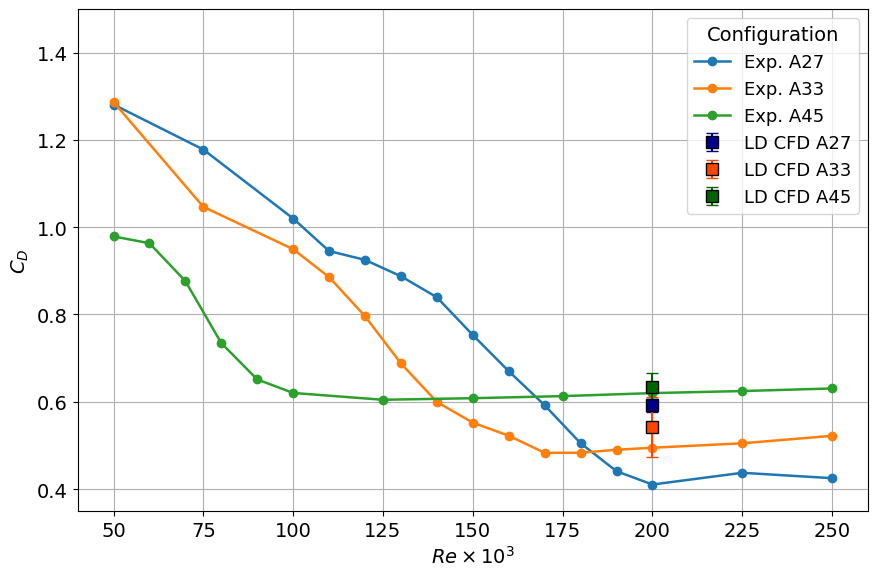

In [37]:
# Missing CFD Cd files are skipped unless you enter Cd_mean manually in CFD_CD_RUNS.
plot_cd_vs_re_with_cfd(
    results_df,
    cfd_cd_df=cfd_cd_df[np.isfinite(cfd_cd_df["Cd_mean"])],
    trip_mm=[0.94],
    include_clean=False,
    angles=[27,33,45],
    show_experimental_errorbars=False,
    show_values=False,
    ylim=(0.35, 1.5),
    show_title=False,
    exp_angle_colors={33: "tab:orange", 27: "tab:blue", 45: "tab:green"},

    # CFD domain display/color options:
    cfd_domains_to_plot=["LD",],   # use "WT", "LD", or ["WT", "LD"]
    cfd_domain_angle_colors={
        "WT": {33: "tab:orange", 27: "tab:blue", 45: "tab:green"},
        "LD": {33: "orangered", 27: "darkblue", 45: "darkgreen"},
    },
    cfd_domain_smooth_colors={"LD": "black", "LD": "dimgray"},
)



### CFD/experimental color options

The CFD comparison plotting functions now allow the experimental and CFD colors to be set directly in the function call.

Example for plotting only the 33 degree case with orange experimental data and darkgoldenrod CFD data:

```python
plot_cd_vs_re_with_cfd(
    results_df,
    cfd_cd_df=cfd_cd_df,
    trip_mm=[0.94],
    include_clean=False,
    angles=[33],
    show_values=True,
    exp_angle_colors={33: "orange"},
    cfd_angle_colors={33: "darkgoldenrod"},
)
```

Example for smooth case where the CFD marker should match the black smooth experimental curve:

```python
plot_cd_vs_re_with_cfd(
    results_df,
    cfd_cd_df=cfd_cd_df,
    include_clean=True,
    angles=[],
    show_values=True,
    exp_smooth_color="black",
    cfd_smooth_color="black",
)
```

The same arguments are available in `plot_st_vs_re_with_cfd(...)`.
